<img src="logo.png" alt="Vegeta" width="240">

# Project Onager — land robots. Onager Sentinel SX-1, a wheel-leg reconnaissance unit

The **Onager series** are land robots built on one modular architecture: swappable mission modules, high
autonomy, encrypted and jamming-resistant links, self-diagnostics and redundancy. The first unit is the
**Sentinel SX-1**, the reconnaissance variant of the datasheet: a 380 kg armoured hull on four two-link legs
that each end in a driven wheel. In **wheel mode** the legs are an active suspension and the hub motors drive
(up to 38 km/h on hard ground); in **walking mode** the legs step over obstacles and through terrain wheels
cannot roll over (up to 6 km/h). Sensor turret and telescopic mast on the roof; 70 km of range, 8–24 h on
station.

This notebook is the Sentinel's mechanics end to end, with the Vegeta libraries doing the work:

```
CAD (Dedalus): hull + turret + mast, four wheel-legs, the wheel ─► envelope vs the datasheet, masses, CG
wheel mode: resistance vs the hub motors' torque–speed line ─► top speed, grades, the 0–38 km/h run, range and endurance
walking mode: stance loads on a two-link leg ─► joint torques ─► the joint modules (actuators.py), the speed the modules allow
terrain (ISO 8608) ─► quarter-car with the active leg as suspension ─► tyre and leg loads, hull vibration, pitch, PSD
                      leg and mast modes (Talos modal) ─► frequency diagram against wheel and terrain excitation
operating cases ─► static FEA of the lower and upper leg (Talos), stub axle and knee pin by hand
actuators (Chiron servo model): torque–speed lines, a stand-up from the crouch, currents and the battery
MuJoCo (ChironLab): the Sentinel on a gravel road with a speed bump, a hub motor fails, a wheel seizes ─► two responses, movies
```

Every input is explicit and coarse (catalogue actuators, assumed tyre and material data). Compare, record,
then drive the real machine over a real kerb.

In [ ]:
# DEBUG: test the notebook end to end before the full run. On: FEA and CFD are mocked (vegeta.mock: fixed numbers,
# seconds instead of hours, the result cache off). Turn it on here or from the shell:
#   VEGETA_DEBUG=1 jupyter nbconvert --to notebook --execute <notebook>.ipynb --output <notebook>-run.ipynb
DEBUG = False
from vegeta import mock
DEBUG = mock.setup(DEBUG)

In [1]:
import json, math, shutil, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch
from tqdm.auto import tqdm
from vegeta import dedalus, talos, chronos, chiron
from vegeta.dedalus import viz as dviz
from vegeta.talos import viz as tviz
from vegeta.chiron import viz as cviz
sys.path.insert(0, "designs")
import actuators as act                   # the shared actuator / motor / joint library (designs/actuators.py)
import gait                               # the shared gait kinematics (two-link inverse kinematics)
import onager_robot as orb, onager_controller as oc, onager_scenario as osc   # the Sentinel in ChironLab (designs/)

RUNS = Path("_runs/onager_sentinel"); shutil.rmtree(RUNS, ignore_errors=True); RUNS.mkdir(parents=True)
OUT = Path("output/20_onager_sentinel"); OUT.mkdir(parents=True, exist_ok=True)
design_file = RUNS / "onager.py"
shutil.copy(Path("designs/onager.py"), design_file)
design = dedalus.load_design(f"{design_file}:OnagerSentinel")
G = 9.81
SPEC = pd.Series({"height [m]": 2.1, "length [m]": 2.6, "width [m]": 1.6, "mass [kg]": 380, "speed, wheels [km/h]": 38,
                  "speed, walking [km/h]": 6, "operating range [km]": 70, "endurance [h]": "8–24"}, name="Onager Sentinel SX-1 — datasheet")
display(SPEC.to_frame())
pd.DataFrame(design.params.table()).set_index("name")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Onager Sentinel SX-1 — datasheet
height [m],2.1
length [m],2.6
width [m],1.6
mass [kg],380
"speed, wheels [km/h]",38
"speed, walking [km/h]",6
operating range [km],70
endurance [h],8–24


,default,units,min,max,description
name,,,,,
part,robot,NaN,NaN,NaN,what to build
hull_length,2000.0,mm,400.0,NaN,hull length (the datasheet's 2.6 m is over the...
hull_width,780.0,mm,200.0,NaN,
hull_height,520.0,mm,100.0,NaN,
hull_chamfer,60.0,mm,1.0,NaN,chamfer of the hull edges (the armour facets)
hull_bottom,760.0,mm,100.0,NaN,ground clearance of the hull floor when standing
shoulder_x,900.0,mm,50.0,NaN,"shoulders from the hull centre, fore and aft"
shoulder_boss_diameter,220.0,mm,20.0,NaN,shoulder actuator housing on the hull side
shoulder_boss_length,90.0,mm,10.0,NaN,


## 1. The machine

The hull is a chamfered armour box with the sensor cluster on the glacis, the turret and the stowed mast on the
roof; the shoulders sit in bosses on the hull sides. Each leg is two machined aluminium H-section plates
(shoulder → knee → stub axle) and a 560 mm wheel with the hub motor inside. The standing pose has the upper
leg 40° back and the lower leg 55° forward, so the wheels sit 108 mm ahead of the shoulders. The datasheet's
envelope (2.6 × 1.6 × 2.1 m) fixes the shoulder spacing, the hull width and the mast height.

shoulder 0.988 m above the ground | wheel axle 108 mm ahead of the shoulder | hull floor 760 mm | wheelbase 1.80 m, track 1.39 m


,CAD [m],datasheet [m]
length,2.576,2.6
width,1.568,1.6
height,2.100,2.1


/home/user/vegeta/vegeta-cli/src/vegeta/dedalus/viz.py:108: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


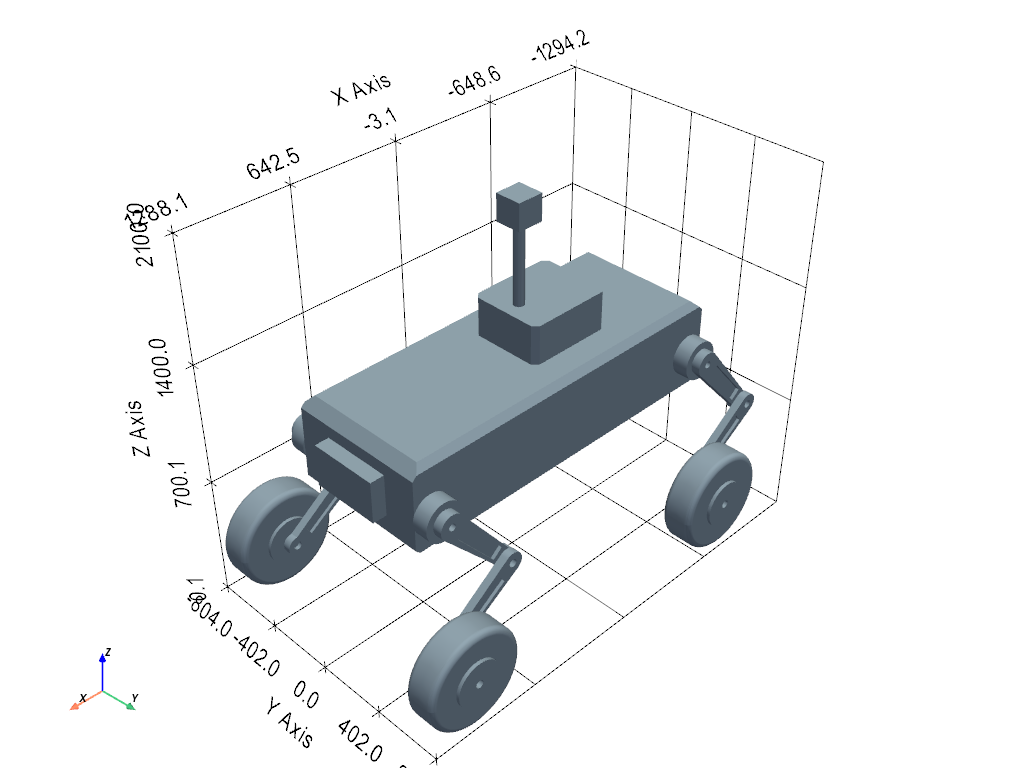

In [2]:
p = design.resolve()
parts = {k: design.generate(part=k) for k in ("robot", "hull", "upper_leg", "lower_leg", "wheel")}
cad = {k: g.export(RUNS / "cad" / k, stl_tolerance=0.1) for k, g in parts.items()}
overall = design.overall(p)
envelope = pd.DataFrame({"CAD [m]": {k: overall[k] / 1000 for k in ("length", "width", "height")},
                         "datasheet [m]": {"length": SPEC["length [m]"], "width": SPEC["width [m]"], "height": SPEC["height [m]"]}})
geo = orb.geometry()
print(f"shoulder {geo['shoulder_height']:.3f} m above the ground | wheel axle {geo['axle_x'] * 1000:.0f} mm ahead of the shoulder | hull floor {p['hull_bottom']:.0f} mm | wheelbase {geo['wheelbase']:.2f} m, track {geo['track']:.2f} m")
display(envelope.round(3))
dviz.show(dviz.plot3d(parts["robot"]))

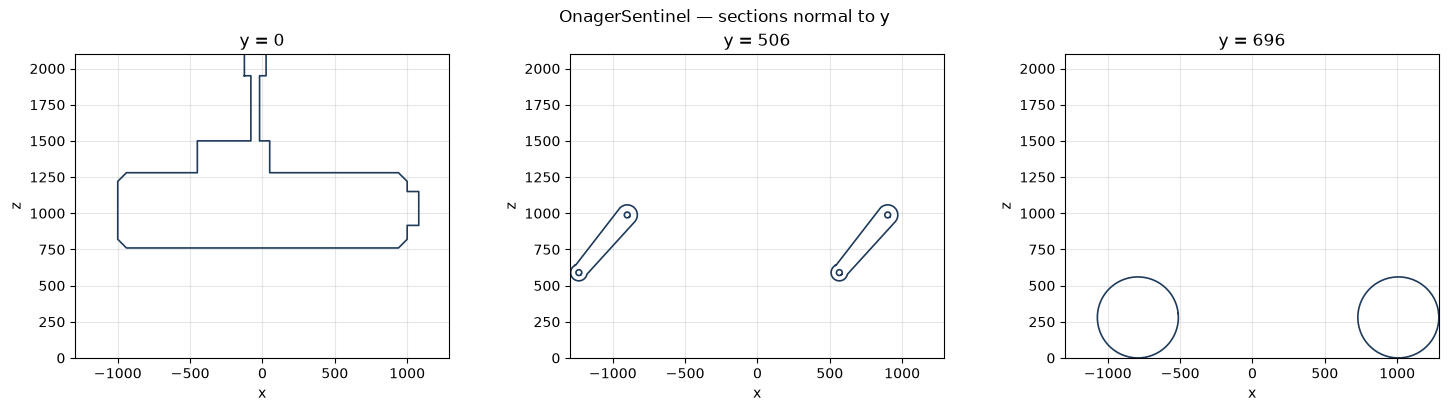

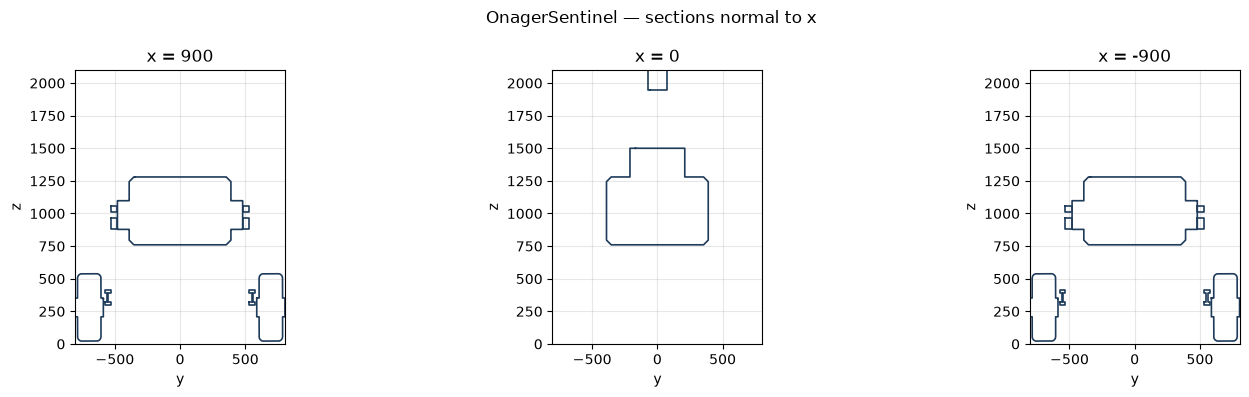

In [3]:
fig = dviz.plot_sections(parts["robot"], normal="y", positions=[0.0, geo["y_upper"] * 1000, geo["y_wheel"] * 1000], cols=3)   # hull centre, leg plane, wheel plane
fig = dviz.plot_sections(parts["robot"], normal="x", positions=[p["shoulder_x"], 0.0, -p["shoulder_x"]], cols=3)

### Mass budget

The armour shell is 3 mm Al 5083 over the CAD's surface area, the legs are the CAD volumes in Al 7075-T6, the
actuators come from the shared catalogue (`designs/actuators.py`: eight `cycloidal 800 Nm, brake` joint modules and
four `hub motor 3 kW`), the rest is listed. The CAD numbers stored in `onager_robot.py` are checked against the
parts just built.

In [4]:
cad_num = orb.cad_numbers(orb.design_params(), recompute=True)
drift = {k: abs(cad_num[k] / orb.CAD[k] - 1) for k in ("hull_surface_area", "upper_leg_volume", "lower_leg_volume", "wheel_volume")}
assert max(drift.values()) < 0.02, drift
budget = orb.mass_budget(orb.design_params(), cad_num)
mass = pd.DataFrame({"mass [kg]": budget})
M_TOTAL = mass["mass [kg]"].sum(); W = M_TOTAL * G
mass.loc["TOTAL"] = M_TOTAL
print(f"total {M_TOTAL:.1f} kg against the datasheet's {SPEC['mass [kg]']} kg ({100 * (M_TOTAL / SPEC['mass [kg]'] - 1):+.0f} %) | per corner {W / 4:.0f} N")
print("catalogue:"); display(act.table()[["kind", "mass_g", "stall_Nm", "rated_Nm", "no_load_rpm", "self_locking"]].tail(3))
mass.round(1)

total 407.5 kg against the datasheet's 380 kg (+7 %) | per corner 1000 N
catalogue:


,kind,mass_g,stall_Nm,rated_Nm,no_load_rpm,self_locking
key,,,,,,
"cycloidal 400 Nm, brake",industrial module,6500.0,400.0,150.0,60,True
hub motor 3 kW,hub motor,9000.0,240.0,60.0,500,False
"cycloidal 800 Nm, brake",industrial module,11000.0,800.0,300.0,40,True


,mass [kg]
"armour shell, 3 mm Al 5083 (from CAD area)",53.3
"upper legs 4x (Al 7075-T6, from CAD)",30.5
"lower legs 4x (Al 7075-T6, from CAD)",23.8
"leg actuators 8x (cycloidal 800 Nm, brake; 11.0 kg each)",88.0
hub motors 4x (hub motor 3 kW; 9.0 kg each),36.0
"frame, mounts, hatches",28.0
wheels: tyres + rims 4x,44.0
battery 48 V LFP 6 kWh,55.0
"sensors: E/O-IR head, lidar, acoustic, mast",22.0
"computer, radios, relay, IMU",12.0


In [5]:
robot = orb.onager(cad=cad_num)
lab_flat = orb.onager_lab(chiron.Flat(), robot=robot)
ep_stand = lab_flat.run(oc.Stand(), duration=2.0, rules=None, settle=0.0)
fz_stand = np.asarray(ep_stand.log["foot_force"])[-1, :, 2]
com_stand = np.asarray(ep_stand.log["com"])[-1]
sag = np.asarray(ep_stand.log["body_pos"])[0, 0, 2] - np.asarray(ep_stand.log["body_pos"])[-1, 0, 2]   # > 0: the hull settles lower than the nominal pose
REAR_SHARE = fz_stand[2:].sum() / fz_stand.sum()
print(f"ChironLab standing: CG {com_stand[0] * 1000:+.0f} mm from the hull centre, {com_stand[2]:.3f} m up | corner loads FL FR RL RR {fz_stand.round(0)} N | rear pair {100 * REAR_SHARE:.0f} % | hull {abs(sag) * 1000:.0f} mm {'below' if sag > 0 else 'above'} the nominal pose under the servos (the feed-forward assumes equal corner shares)")
print(f"battery at x = {robot.battery_x:+.2f} m ({orb.ASSUMPTIONS['battery_position']})")

ChironLab standing: CG +7 mm from the hull centre, 0.800 m up | corner loads FL FR RL RR [ 940.  940. 1060. 1060.] N | rear pair 53 % | hull 24 mm above the nominal pose under the servos (the feed-forward assumes equal corner shares)
battery at x = +0.60 m (on the hull floor, at the x that would put the standing CG over the centre of the four tyre contact patches (x = axle_x, 108 mm ahead of the hull centre: the lower legs slant forward) but no further forward than BATTERY_X_MAX = 0.6 m (the front compartment): the knee modules sit 0.33 m behind the shoulders, so the CG ends ~50 mm behind the patch centre and the rear pair carries ~53 % (notebook 20 §1))


## 2. Wheel mode: resistance against the hub motors, the 0–38 km/h run, range and endurance

Four `hub motor 3 kW` (240 N·m stall, 500 rpm no-load, 60 N·m continuous) on 560 mm wheels. The resistance is
rolling (`C_RR · W cos θ`), grade (`W sin θ`) and air (`½ ρ C_d A v²`); the tractive force is the sum of the four
motors on their torque–speed lines, capped by tyre friction. Where the two curves cross is the top speed on that
grade. The 0–38 km/h run integrates the same lines with the wheels' inertia; the battery (48 V, 6 kWh LFP) sets
the range at a cruising speed and the endurance on station.

continuous tractive force 857 N: the grade the motors climb all day on gravel is 11° (19 %); steeper climbs run above the rated torque (minutes, not hours)


,top speed on asphalt [km/h],top speed on gravel [km/h]
0 % grade,48.6,47.7
10 % grade,43.2,42.3
20 % grade,37.8,37.0
30 % grade,32.7,31.8


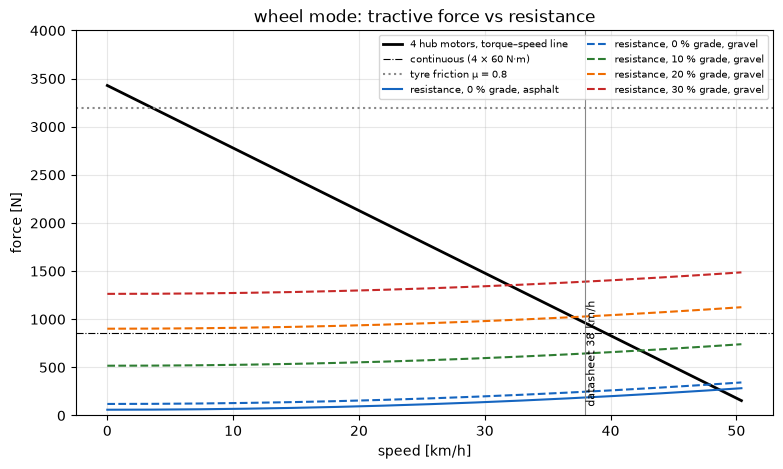

In [6]:
HUB = act.get(orb.WHEEL_MOTOR); R_W = geo["r_wheel"]
W0_HUB = HUB.no_load_rpm * 2 * math.pi / 60
RHO_AIR, C_D, A_FRONT = 1.2, 1.0, 1.9          # frontal area: 1.6 m wide, hull + turret ≈ 1.2 m tall (inputs)
C_RR = {"asphalt": 0.015, "gravel": 0.03, "soft soil": 0.08}
MU_TYRE = 0.8                                  # knobbly tyre on dry gravel / concrete (input)
GRADES_PCT = [0, 10, 20, 30]
def resistance(v, c_rr, grade_pct):
    th = math.atan(grade_pct / 100)
    return W * (c_rr * math.cos(th) + math.sin(th)) + 0.5 * RHO_AIR * C_D * A_FRONT * v**2
def tractive(v, n_motors=4):
    return n_motors * HUB.stall_Nm * max(0.0, 1 - abs(v) / R_W / W0_HUB) / R_W
F_TRAC_RATED = 4 * HUB.rated_Nm / R_W
v_grid = np.linspace(0, 14, 400)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(v_grid * 3.6, [tractive(v) for v in v_grid], "k", lw=2, label="4 hub motors, torque–speed line")
ax.axhline(min(F_TRAC_RATED, MU_TYRE * W), color="k", ls="-.", lw=0.8, label=f"continuous (4 × {HUB.rated_Nm:.0f} N·m)")
ax.axhline(MU_TYRE * W, color="#888", ls=":", label=f"tyre friction μ = {MU_TYRE}")
top_speed = {}
for gr, col in zip(GRADES_PCT, ("#1565c0", "#2e7d32", "#ef6c00", "#c62828")):
    for surf, ls in (("asphalt", "-"), ("gravel", "--")):
        res = np.array([resistance(v, C_RR[surf], gr) for v in v_grid])
        trac = np.array([tractive(v) for v in v_grid])
        ok = np.where(trac >= res)[0]
        top_speed[(gr, surf)] = v_grid[ok[-1]] if len(ok) else 0.0
        if surf == "gravel" or gr == 0:
            ax.plot(v_grid * 3.6, res, ls, color=col, label=f"resistance, {gr} % grade, {surf}")
ax.axvline(SPEC["speed, wheels [km/h]"], color="#888", lw=0.8); ax.text(SPEC["speed, wheels [km/h]"], 50, " datasheet 38 km/h", rotation=90, fontsize=8, va="bottom")
ax.set(xlabel="speed [km/h]", ylabel="force [N]", ylim=(0, 4000), title="wheel mode: tractive force vs resistance"); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.3)
tops = pd.DataFrame({surf: {f"{gr} % grade": top_speed[(gr, surf)] * 3.6 for gr in GRADES_PCT} for surf in ("asphalt", "gravel")}).round(1)
tops.columns = [f"top speed on {s} [km/h]" for s in tops.columns]
grade_cont = math.degrees(math.asin(min(1.0, (F_TRAC_RATED - C_RR["gravel"] * W) / W)))
print(f"continuous tractive force {F_TRAC_RATED:.0f} N: the grade the motors climb all day on gravel is {grade_cont:.0f}° ({100 * math.tan(math.radians(grade_cont)):.0f} %); steeper climbs run above the rated torque (minutes, not hours)")
tops

,time_s,distance_m,energy_Wh,peak_motor_current_A,peak_battery_power_kW
"asphalt, flat",2.45,15.50,14.04,139.93,28.21
"gravel, flat",2.55,16.24,14.56,139.93,28.21
"gravel, 10 % grade",3.58,24.40,19.70,139.93,28.21


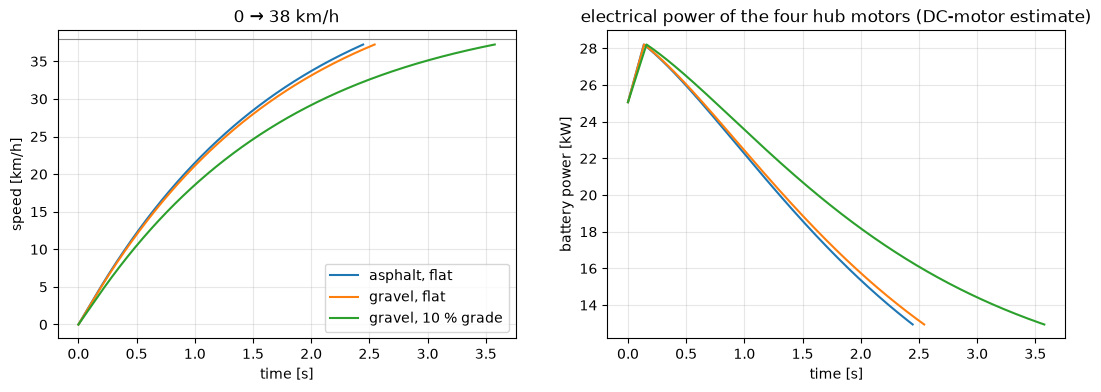

In [7]:
I_WHEEL = 0.5 * (orb.PARTS_KG["wheels: tyres + rims 4x"] / 4) * R_W**2 + orb.WHEEL_ARMATURE      # tyre + rim as a disc, plus the rotor
M_EFF = M_TOTAL + 4 * I_WHEEL / R_W**2
def accel_run(c_rr, grade_pct=0, v_end=None, t_max=30.0, dt=1e-3):
    v_end = v_end or SPEC["speed, wheels [km/h]"] / 3.6 * 0.98
    t, v, s, E = 0.0, 0.0, 0.0, 0.0
    hist = []
    while v < v_end and t < t_max:
        F = min(tractive(v), MU_TYRE * W) - resistance(v, c_rr, grade_pct)
        tau = min(tractive(v), MU_TYRE * W) / 4 * R_W
        i_motor = tau / HUB.stall_Nm * HUB.stall_A                           # DC-motor estimate: current ∝ torque
        P_el = 4 * (tau * v / R_W + i_motor**2 * (HUB.voltage_V / HUB.stall_A))   # mechanical + copper loss
        hist.append((t, v, tau, i_motor, P_el))
        v += F / M_EFF * dt; s += v * dt; E += P_el * dt; t += dt
    h = np.array(hist)
    return {"time_s": t, "distance_m": s, "energy_Wh": E / 3600, "peak_motor_current_A": h[:, 3].max(), "peak_battery_power_kW": h[:, 4].max() / 1000, "hist": h}
runs = {"asphalt, flat": accel_run(C_RR["asphalt"]), "gravel, flat": accel_run(C_RR["gravel"]), "gravel, 10 % grade": accel_run(C_RR["gravel"], 10)}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, r in runs.items():
    axes[0].plot(r["hist"][:, 0], r["hist"][:, 1] * 3.6, label=name); axes[1].plot(r["hist"][:, 0], r["hist"][:, 4] / 1000, label=name)
axes[0].axhline(SPEC["speed, wheels [km/h]"], color="#888", lw=0.8); axes[0].set(xlabel="time [s]", ylabel="speed [km/h]", title="0 → 38 km/h"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set(xlabel="time [s]", ylabel="battery power [kW]", title="electrical power of the four hub motors (DC-motor estimate)"); axes[1].grid(alpha=0.3)
accel = pd.DataFrame({k: {kk: v for kk, v in r.items() if kk != "hist"} for k, r in runs.items()}).T
accel.round(2)

In [8]:
E_BATT_WH, USABLE, ETA_DRIVE = 6000.0, 0.9, 0.85      # 48 V LFP pack (input), usable fraction, motor + inverter efficiency
P_HOTEL = {"on station (sensors, computer, radio)": 220.0, "driving (adds the mast stowed, lidar spinning)": 350.0}   # W (inputs)
def range_km(v_kmh, c_rr):
    v = v_kmh / 3.6
    P = resistance(v, c_rr, 0) * v / ETA_DRIVE + P_HOTEL["driving (adds the mast stowed, lidar spinning)"]
    hours = E_BATT_WH * USABLE / P
    return {"power [W]": P, "hours": hours, "range [km]": hours * v_kmh}
endurance = pd.DataFrame({f"{v} km/h on {surf}": range_km(v, C_RR[surf]) for v in (11, 20, 38) for surf in ("asphalt", "gravel")}).T
endurance.loc["on station, 0 km/h"] = {"power [W]": P_HOTEL["on station (sensors, computer, radio)"], "hours": E_BATT_WH * USABLE / P_HOTEL["on station (sensors, computer, radio)"], "range [km]": 0.0}
mixed = 0.3 * endurance.loc["11 km/h on gravel", "power [W]"] + 0.7 * P_HOTEL["on station (sensors, computer, radio)"]
endurance.loc["mission: 30 % moving at 11 km/h on gravel, 70 % on station"] = {"power [W]": mixed, "hours": E_BATT_WH * USABLE / mixed, "range [km]": E_BATT_WH * USABLE / mixed * 0.3 * 11}
print(f"battery {E_BATT_WH / 1000:.0f} kWh ({orb.PARTS_KG['battery 48 V LFP 6 kWh']:.0f} kg) | datasheet: {SPEC['operating range [km]']} km, {SPEC['endurance [h]']} h")
endurance.round(1)

battery 6 kWh (55 kg) | datasheet: 70 km, 8–24 h


,power [W],hours,range [km]
11 km/h on asphalt,603.8,8.9,98.4
11 km/h on gravel,819.4,6.6,72.5
20 km/h on asphalt,971.9,5.6,111.1
20 km/h on gravel,1363.9,4.0,79.2
38 km/h on asphalt,2672.1,2.0,76.8
38 km/h on gravel,3416.8,1.6,60.1
"on station, 0 km/h",220.0,24.5,0.0
"mission: 30 % moving at 11 km/h on gravel, 70 % on station",399.8,13.5,44.6


## 3. Walking mode: stance loads, joint torques, the joint modules, and how fast the legs can step

In walking mode the wheels are braked and the legs step. A stance wheel carries a half-sine ground reaction
over its contact time; with duty factor β the peak per wheel is `(π/2) · W / (4β)` — a walk (β = 0.75) puts
2.1 kN on a wheel. The force acts at the tyre's contact point, 280 mm below the axle, so both joints see the
wheel radius in their lever arms. The torques are swept over a stance (the wheel from ahead of the shoulder to
behind it, hull at the standing height) and compared with the `cycloidal 800 Nm, brake` module the catalogue
selects at SF 1.5. The module's 40 rpm no-load speed then limits the swing return and with it the walking speed.

peak joint torque 1274 N·m: no catalogue module holds it at SF 1.5 (ValueError); the cycloidal 800 Nm, brake has SF 0.63 at the walk's peak — the forward-slanted lower leg gives the knee a 442 mm lever: walk with a lower duty (the amble) or a longer module | standing knee torque 469 N·m against 300 N·m continuous: the holding brake carries the standing load


,duty,peak wheel force [N],peak shoulder [Nm],peak knee [Nm],SF on stall (800 Nm)
walk,0.75,2093.35,657.58,1019.20,0.78
amble,0.60,2616.69,821.97,1274.00,0.63
"standing, rear wheel",1.00,1059.39,114.51,468.61,1.71


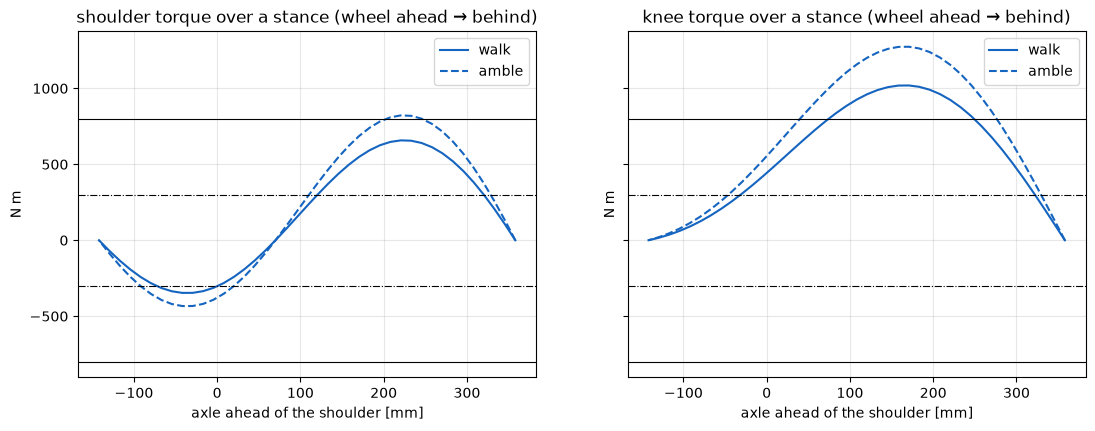

In [9]:
LEG = act.get(orb.LEG_ACTUATOR)
L1, L2, R_WHEEL = geo["L1"], geo["L2"], geo["r_wheel"]
H_AXLE = geo["h_axle"]
BETA = {"walk": 0.75, "amble": 0.6}
def wheel_peak(W, beta): return (math.pi / 2) * W / (4 * beta)
def leg_torques(x_axle, fx, fz, fy=0.0):
    """Shoulder and knee torques [N m] holding a ground force (fx forward, fz up) at the contact point below an axle x_axle [m] ahead of the shoulder, hull at the standing height."""
    ik = gait.ik_two_link_planar(x_axle * 1000, -H_AXLE * 1000, L1 * 1000, L2 * 1000)
    if ik is None:
        return float("nan"), float("nan")
    a1, a2 = map(math.radians, ik)
    knee = np.array([-L1 * math.sin(a1), -L1 * math.cos(a1)])
    contact = np.array([x_axle, -H_AXLE - R_WHEEL])
    tau_sh = contact[0] * fz - contact[1] * fx
    tau_kn = (contact[0] - knee[0]) * fz - (contact[1] - knee[1]) * fx
    return tau_sh, tau_kn
STANCE = 0.50                                   # stance travel of a wheel in walking mode [m] (input: about half the leg)
xs = np.linspace(geo["axle_x"] + STANCE / 2, geo["axle_x"] - STANCE / 2, 41)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
torque_rows = {}
for (gname, beta), ls in zip(BETA.items(), ("-", "--")):
    Fz = wheel_peak(W, beta) * np.sin(np.pi * np.linspace(0, 1, len(xs)))
    Fx = 0.3 * Fz * np.cos(np.pi * np.linspace(0, 1, len(xs)))                  # braking then pushing
    th = np.array([leg_torques(x, fx, fz) for x, fx, fz in zip(xs, Fx, Fz)])
    axes[0].plot(xs * 1000, th[:, 0], ls, color="#1565c0", label=gname); axes[1].plot(xs * 1000, th[:, 1], ls, color="#1565c0", label=gname)
    torque_rows[gname] = {"duty": beta, "peak wheel force [N]": wheel_peak(W, beta), "peak shoulder [Nm]": float(np.nanmax(np.abs(th[:, 0]))), "peak knee [Nm]": float(np.nanmax(np.abs(th[:, 1])))}
tau_stand = leg_torques(geo["axle_x"], 0.0, W / 4 * 2 * REAR_SHARE)
torque_rows["standing, rear wheel"] = {"duty": 1.0, "peak wheel force [N]": W / 4 * 2 * REAR_SHARE, "peak shoulder [Nm]": abs(tau_stand[0]), "peak knee [Nm]": abs(tau_stand[1])}
for ax, name in zip(axes, ("shoulder", "knee")):
    for v, lab_ in ((LEG.rated_Nm, "continuous"), (LEG.stall_Nm, "stall")):
        ax.axhline(v, color="k", lw=0.8, ls="-." if lab_ == "continuous" else "-"); ax.axhline(-v, color="k", lw=0.8, ls="-." if lab_ == "continuous" else "-")
    ax.set(title=f"{name} torque over a stance (wheel ahead → behind)", xlabel="axle ahead of the shoulder [mm]", ylabel="N m"); ax.grid(alpha=0.3); ax.legend()
torques = pd.DataFrame(torque_rows).T
peak = torques[["peak shoulder [Nm]", "peak knee [Nm]"]].max().max()
torques["SF on stall (800 Nm)"] = LEG.stall_Nm / torques[["peak shoulder [Nm]", "peak knee [Nm]"]].max(axis=1)
try:
    chosen = act.select(peak, sf=1.5, kind="industrial module"); choice = f"act.select(sf=1.5) picks {chosen.key} ({chosen.mass_g / 1000:.1f} kg)"
except Exception as e:
    choice = f"no catalogue module holds it at SF 1.5 ({type(e).__name__}); the {LEG.key} has SF {LEG.stall_Nm / peak:.2f} at the walk's peak — the forward-slanted lower leg gives the knee a {L2 * math.sin(geo['a2']) * 1000:.0f} mm lever: walk with a lower duty (the amble) or a longer module"
print(f"peak joint torque {peak:.0f} N·m: {choice} | standing knee torque {abs(tau_stand[1]):.0f} N·m against {LEG.rated_Nm:.0f} N·m continuous: the holding brake carries the standing load")
torques.round(2)

In [10]:
W0_LEG = LEG.no_load_rpm * 2 * math.pi / 60
SWING_SPEED_FRACTION = 0.6                      # a loaded joint moves at ~60 % of its no-load speed (torque left for the leg's inertia; input)
leg_len = H_AXLE + R_WHEEL
def v_walk_max(beta, stance=STANCE, sweep_fraction=1.0):
    """Walking speed the swing return allows: the leg must come back `sweep_fraction × stance` (rolling stance: less) in (1 − β) of the stride."""
    w_sw = SWING_SPEED_FRACTION * W0_LEG
    T_min = sweep_fraction * stance / leg_len / ((1 - beta) * w_sw)
    return stance / (beta * T_min)
walk_speed = pd.DataFrame({g: {"pure walk (wheels braked) [km/h]": v_walk_max(b) * 3.6, "wheel-walk (wheels roll half the stance) [km/h]": v_walk_max(b, sweep_fraction=0.5) * 3.6,
                               "stride frequency at the limit [Hz]": v_walk_max(b) / STANCE * b} for g, b in BETA.items()}).T
f_hold = min(abs(tau_stand[1]) / LEG.stall_Nm, 1.0)                         # current fraction of stall at the standing torque (DC motor at rest)
hold = {"brakes on (self-locking module) [W]": 4 * LEG.holding_power(abs(tau_stand[1])), "brakes off, four knees hold the hull [W]": 4 * f_hold * LEG.stall_A * LEG.voltage_V}
print(f"datasheet walking speed {SPEC['speed, walking [km/h]']} km/h — the {LEG.no_load_rpm:.0f} rpm module allows {walk_speed.iloc[0, 0]:.1f} km/h in a pure walk: 6 km/h needs a ~{6 / walk_speed.iloc[0, 0] * LEG.no_load_rpm:.0f} rpm module or the wheel-walk ({walk_speed.iloc[0, 1]:.1f} km/h)")
print(f"holding the standing pose: {hold['brakes on (self-locking module) [W]']:.0f} W with the brakes, {hold['brakes off, four knees hold the hull [W]']:.0f} W without (DC-motor estimate: current ∝ torque) — the brake is load-bearing equipment")
walk_speed.round(2)

datasheet walking speed 6 km/h — the 40 rpm module allows 3.0 km/h in a pure walk: 6 km/h needs a ~81 rpm module or the wheel-walk (6.0 km/h)
holding the standing pose: 0 W with the brakes, 20244 W without (DC-motor estimate: current ∝ torque) — the brake is load-bearing equipment


,pure walk (wheels braked) [km/h],wheel-walk (wheels roll half the stance) [km/h],stride frequency at the limit [Hz]
walk,2.98,5.96,1.24
amble,5.96,11.92,1.99


## 4. Terrain and vibration: the active leg as suspension, tyre and leg loads, the hull and the mast

Each corner is a quarter car: the sprung quarter of the hull on the leg's servo stiffness (the knee's `kp`
expressed as a vertical rate at the wheel, `kp / (L₂ sin a₂)²`, with the matching `kd` as the damper) and the
unsprung mass (tyre, rim, hub motor, half the lower leg) on the tyre stiffness. Profiles are ISO 8608 classes
from their PSD (seeded): an asphalt road at 36 km/h, a gravel track with rocks at 22 km/h, a rocky field with
rocks and a drop at 9 km/h. The rear corner runs the same profile delayed by the wheelbase, so the hull's
pitch — what the sensor gimbal must cancel — follows too. The lower leg's modes with the wheel on it and the
mast's modes with the sensor head come from Talos.

In [11]:
M_UNSPRUNG = orb.PARTS_KG["wheels: tyres + rims 4x"] / 4 + HUB.mass_g / 1000 + budget["lower legs 4x (Al 7075-T6, from CAD)"] / 8
M_SPRUNG_CORNER = (M_TOTAL - 4 * M_UNSPRUNG) / 4
LEVER_KNEE = L2 * math.sin(geo["a2"])                   # vertical travel of the wheel per rad of knee angle [m]
K_SUSP = orb.LEG_KP / LEVER_KNEE**2                      # N/m at the wheel: the knee servo as the spring
C_SUSP = orb.LEG_KD / LEVER_KNEE**2
ZETA = C_SUSP / (2 * math.sqrt(K_SUSP * M_SPRUNG_CORNER))
K_TYRE = 150e3                                           # N/m, 560 mm foam-filled knobbly tyre (input)
f_heave = math.sqrt(K_SUSP / M_SPRUNG_CORNER) / (2 * math.pi)
f_hop = math.sqrt((K_TYRE + K_SUSP) / M_UNSPRUNG) / (2 * math.pi)
print(f"sprung {M_SPRUNG_CORNER:.0f} kg per corner on k = {K_SUSP / 1000:.1f} kN/m (ζ = {ZETA:.2f}): heave {f_heave:.2f} Hz | unsprung {M_UNSPRUNG:.0f} kg on the tyre: hop {f_hop:.1f} Hz | static sag {M_SPRUNG_CORNER * G / K_SUSP * 1000:.0f} mm (ChironLab: {abs(sag) * 1000:.0f} mm with the feed-forward carrying the standing load)")

def iso8608_profile(length_m, dx, gd_n0, seed, n0=0.1, n_min=0.02, n_max=8.0, n_waves=400):
    rng = np.random.default_rng(seed)
    x = np.arange(0, length_m, dx)
    ns = np.linspace(n_min, n_max, n_waves); dn = ns[1] - ns[0]
    amps = np.sqrt(2 * gd_n0 * (ns / n0) ** -2 * dn)
    phases = rng.uniform(0, 2 * math.pi, n_waves)
    return x, (amps[None, :] * np.sin(2 * math.pi * ns[None, :] * x[:, None] + phases[None, :])).sum(axis=1)
def add_rocks(x, z, height_m, width_m, spacing_m, seed):
    rng = np.random.default_rng(seed); z = z.copy()
    centres = np.arange(spacing_m, x[-1] - spacing_m, spacing_m)
    for xc in centres + rng.uniform(-0.3, 0.3, len(centres)):
        mask = np.abs(x - xc) < width_m / 2
        z[mask] += height_m * np.cos(math.pi * (x[mask] - xc) / width_m)
    return z
def add_drop(x, z, at_m, depth_m):
    z = z.copy(); z[x > at_m] -= depth_m; return z
def quarter_car(x, z_road, speed, dt=5e-4):
    t = np.arange(0, x[-1] / speed, dt)
    zr = np.interp(t * speed, x, z_road)
    zs = zw = vs = vw = 0.0
    Fs, Ft, As, travel, Zs = (np.zeros_like(t) for _ in range(5))
    for i, z_r in enumerate(zr):
        f_susp = K_SUSP * (zw - zs) + C_SUSP * (vw - vs)
        f_tyre = max(K_TYRE * (z_r - zw), -M_TOTAL * G / 4)
        a_s = f_susp / M_SPRUNG_CORNER; a_w = (f_tyre - f_susp) / M_UNSPRUNG
        vs += a_s * dt; vw += a_w * dt; zs += vs * dt; zw += vw * dt
        Fs[i], Ft[i], As[i], travel[i], Zs[i] = f_susp + M_SPRUNG_CORNER * G, f_tyre + M_TOTAL * G / 4, a_s, zw - zs, zs
    return t, zr, Fs, Ft, As, travel, Zs
TERRAINS = {
    "asphalt road":  {"class": "A/B", "gd": 32e-6,   "speed": 10.0, "length": 150.0, "rocks": None,              "drop": None,         "seed": 1},
    "gravel track":  {"class": "C",   "gd": 256e-6,  "speed": 6.0,  "length": 150.0, "rocks": (0.05, 0.25, 8.0), "drop": None,         "seed": 2},
    "rocky field":   {"class": "E",   "gd": 4096e-6, "speed": 2.5,  "length": 120.0, "rocks": (0.10, 0.30, 3.0), "drop": (90.0, 0.15), "seed": 3},
}
sims = {}
for name, tr in tqdm(TERRAINS.items(), desc="terrains"):
    x, z = iso8608_profile(tr["length"], 0.005, tr["gd"], tr["seed"])
    if tr["rocks"]: z = add_rocks(x, z, *tr["rocks"], seed=tr["seed"] + 10)
    if tr["drop"]: z = add_drop(x, z, *tr["drop"])
    t, zr, Fs, Ft, As, travel, Zs = quarter_car(x, z, tr["speed"])
    z_rear = np.interp(x - geo["wheelbase"], x, z, left=0.0)                           # the rear corner, the wheelbase behind
    _, _, _, _, _, _, Zs_rear = quarter_car(x, z_rear, tr["speed"])
    pitch = np.degrees(np.arctan((Zs[:len(Zs_rear)] - Zs_rear) / geo["wheelbase"]))
    sims[name] = dict(t=t, zr=zr, Fs=Fs, Ft=Ft, As=As, travel=travel, pitch=pitch, pitch_rate=np.gradient(pitch, t[:len(pitch)]), duration_s=t[-1], speed=tr["speed"])
summary = pd.DataFrame({k: {"speed_km_h": s["speed"] * 3.6, "tyre_force_max_N": s["Ft"].max(), "tyre_force_min_N": s["Ft"].min(), "leg_force_max_N": s["Fs"].max(),
                            "hull_accel_rms_g": np.sqrt(np.mean(s["As"] ** 2)) / G, "hull_accel_peak_g": np.abs(s["As"]).max() / G, "travel_max_mm": np.abs(s["travel"]).max() * 1000,
                            "pitch_rms_deg": np.sqrt(np.mean(s["pitch"] ** 2)), "pitch_rate_rms_deg_s": np.sqrt(np.mean(s["pitch_rate"] ** 2)),
                            "airborne_%": 100 * np.mean(s["Ft"] <= 1e-6)} for k, s in sims.items()}).T.round(2)
summary

sprung 79 kg per corner on k = 8.2 kN/m (ζ = 0.38): heave 1.62 Hz | unsprung 23 kg on the tyre: hop 13.2 Hz | static sag 95 mm (ChironLab: 24 mm with the feed-forward carrying the standing load)


terrains:   0%|          | 0/3 [00:00<?, ?it/s]

terrains:  33%|███▎      | 1/3 [00:01<00:02,  1.08s/it]

terrains:  67%|██████▋   | 2/3 [00:01<00:00,  1.36it/s]

terrains: 100%|██████████| 3/3 [00:02<00:00,  1.60it/s]

terrains: 100%|██████████| 3/3 [00:02<00:00,  1.45it/s]

,speed_km_h,tyre_force_max_N,tyre_force_min_N,leg_force_max_N,hull_accel_rms_g,hull_accel_peak_g,travel_max_mm,pitch_rms_deg,pitch_rate_rms_deg_s,airborne_%
asphalt road,36.0,1546.17,489.65,914.27,0.07,0.20,6.18,0.13,1.26,0.00
gravel track,21.6,7088.56,0.00,2913.28,0.45,2.76,71.42,1.04,10.80,9.46
rocky field,9.0,8180.60,0.00,3985.17,0.79,4.15,143.80,2.65,22.18,26.87


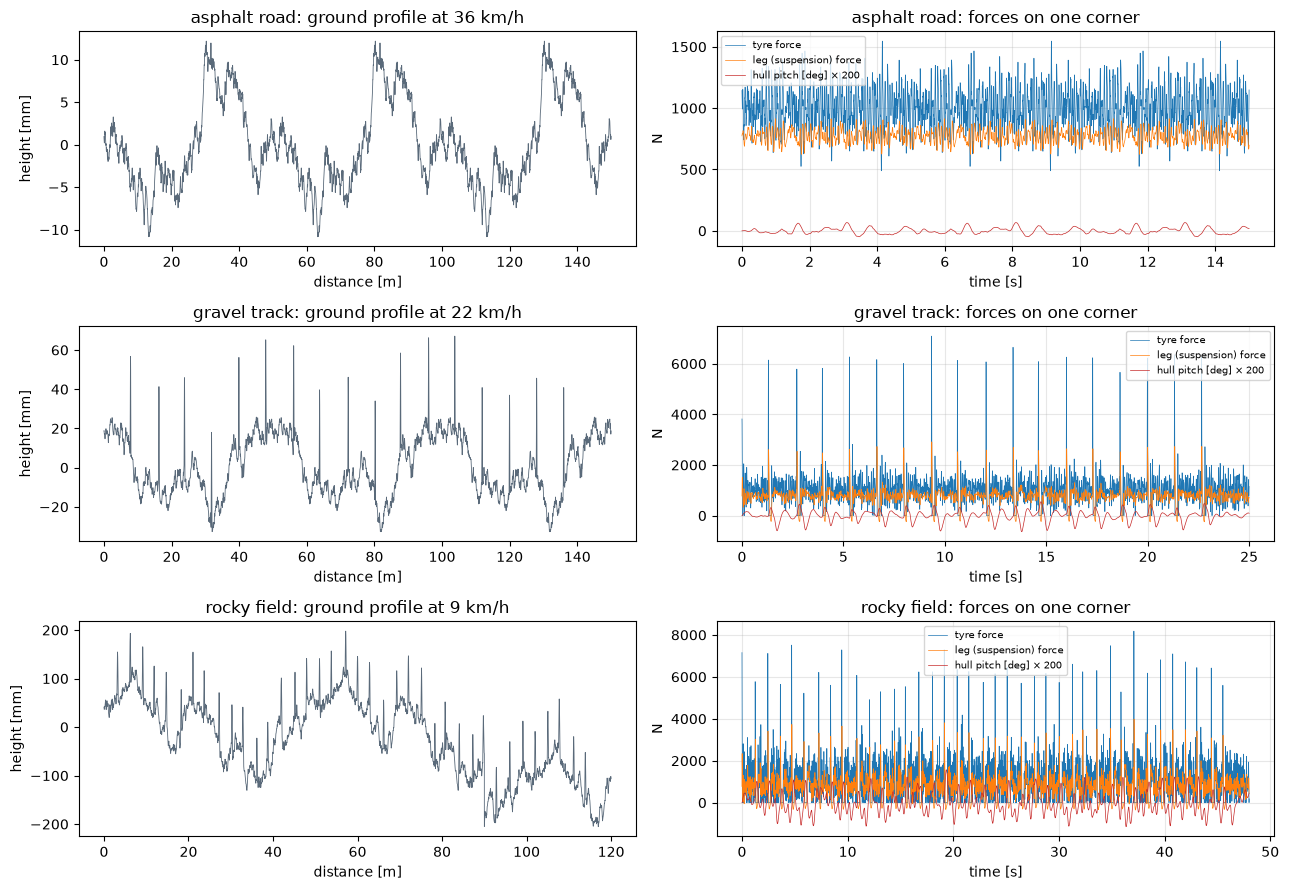

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
for (name, s), (a1, a2) in zip(sims.items(), axes):
    a1.plot(s["t"] * s["speed"], s["zr"] * 1000, lw=0.6, color="#5a6a7a"); a1.set(title=f"{name}: ground profile at {s['speed'] * 3.6:.0f} km/h", xlabel="distance [m]", ylabel="height [mm]")
    a2.plot(s["t"], s["Ft"], lw=0.5, label="tyre force"); a2.plot(s["t"], s["Fs"], lw=0.5, label="leg (suspension) force"); a2.plot(s["t"][:len(s["pitch"])], 200 * s["pitch"], lw=0.5, color="#c62828", label="hull pitch [deg] × 200")
    a2.set(title=f"{name}: forces on one corner", xlabel="time [s]", ylabel="N"); a2.legend(fontsize=7); a2.grid(alpha=0.3)
fig.tight_layout()

talos mesh:   0%|          | 00:00 

talos mesh:   0%|          | 00:02 

import STEP:   0%|          | 00:02 

import STEP:   5%|▌         | 00:02 

import STEP:   5%|▌         | 00:03 

...

done:  90%|█████████ | 00:04       

done: 100%|██████████| 00:04 


*******************************************************************
******        Statistics on Transfer (Write)                 ******

*******************************************************************
******        Transfer Mode = 0  I.E.  As Is       ******
******        Transferring Shape, ShapeType = 0                      ******
** WorkSession : Sending all data
 Step File Name : _runs/onager_sentinel/mast.step(202 ents)  Write  Done


lower leg with the wheel (20 kg at the axle), knee held: [27.1, 77.4, 232.0, 467.2] Hz | mast with the 5.5 kg head: [46.8, 46.8, 219.8, 222.6] Hz (cantilever estimate 48 Hz)


/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:255: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), style="wireframe", color="#9aa5b1", opacity=0.3, line_width=0.5)
/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:323: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


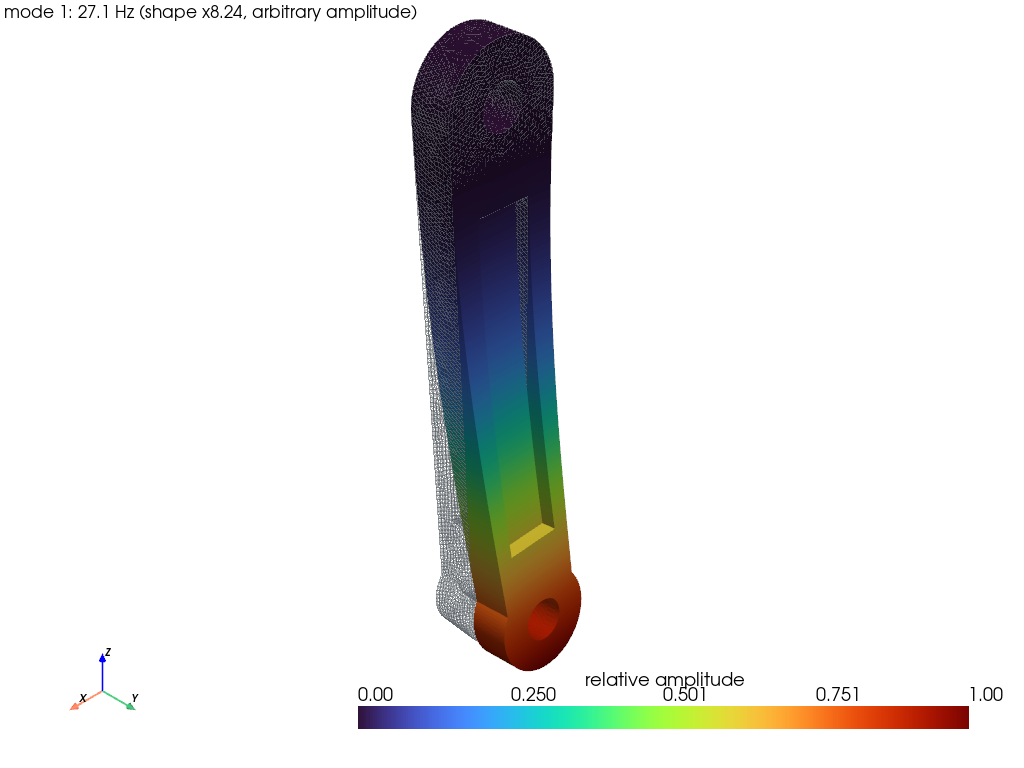

In [13]:
M_WHEEL_T = (orb.PARTS_KG["wheels: tyres + rims 4x"] / 4 + HUB.mass_g / 1000) * 1e-3          # tyre + rim + hub motor at the axle [t]
AL7075 = talos.Material("Al 7075-T6", youngs_modulus=71700.0, poissons_ratio=0.33, density=2.81e-9, yield_strength=503.0, source="handbook, plate; weld-free machined part")
AL6082 = talos.Material("Al 6082-T6 tube", youngs_modulus=70000.0, poissons_ratio=0.33, density=2.7e-9, yield_strength=260.0, source="handbook")
t_low, t_up = p["lower_leg_thickness"], p["upper_leg_thickness"]
ra, rp = p["axle_diameter"] / 2 + 0.5, p["pin_diameter"] / 2 + 0.5
L2mm, L1mm = p["lower_leg_length"], p["upper_leg_length"]
LOWER_REGIONS = [talos.SurfacesInBox("knee", (-ra, -t_low, -ra, ra, t_low, ra)), talos.SurfacesInBox("axle", (-ra, -t_low, -L2mm - ra, ra, t_low, -L2mm + ra))]
UPPER_REGIONS = [talos.SurfacesInBox("shoulder", (-rp, -t_up, -rp, rp, t_up, rp)), talos.SurfacesInBox("knee", (-rp, -t_up, -L1mm - rp, rp, t_up, -L1mm + rp))]
def lower_model(loads, name, masses=()):
    return talos.StructuralModel(cad["lower_leg"].artifacts["step"], "mm-N-MPa", AL7075, LOWER_REGIONS, [talos.FixedSupport("knee")], loads,
                                 talos.MeshSettings(element_size=10.0, min_element_size=3.0), name=name, masses=list(masses))
def upper_model(loads, name):
    return talos.StructuralModel(cad["upper_leg"].artifacts["step"], "mm-N-MPa", AL7075, UPPER_REGIONS, [talos.FixedSupport("shoulder")], loads,
                                 talos.MeshSettings(element_size=10.0, min_element_size=3.0), name=name)
modal = lower_model([], "lower_modal", masses=[talos.PointMass("axle", M_WHEEL_T)])
modal.mesh(RUNS / "lower_modal", progress=True); modes = modal.solve_modes(RUNS / "lower_modal", n_modes=4)
f_leg = modes.metrics["frequencies_hz"]
# the stowed mast: a 60 mm × 3 mm aluminium tube clamped at the turret, the 5.5 kg sensor head on top (Talos modal on a tube built here)
import gmsh
mast_step = RUNS / "mast.step"
ro, ri, Hm = p["mast_diameter"] / 2, p["mast_diameter"] / 2 - 3.0, p["mast_height"]
gmsh.initialize(); gmsh.option.setNumber("General.Terminal", 0); gmsh.option.setNumber("General.Verbosity", 0)
outer = gmsh.model.occ.addCylinder(0, 0, 0, 0, 0, Hm, ro); inner = gmsh.model.occ.addCylinder(0, 0, -1, 0, 0, Hm + 2, ri)
gmsh.model.occ.cut([(3, outer)], [(3, inner)]); gmsh.model.occ.synchronize(); gmsh.write(str(mast_step)); gmsh.finalize()
M_HEAD_T = 0.25 * orb.PARTS_KG["sensors: E/O-IR head, lidar, acoustic, mast"] * 1e-3
mast_model = talos.StructuralModel(mast_step, "mm-N-MPa", AL6082, [talos.SurfacesOnPlane("base", "z", 0.0), talos.SurfacesOnPlane("top", "z", Hm)],
                                   [talos.FixedSupport("base")], [], talos.MeshSettings(element_size=6.0, min_element_size=2.0), name="mast_modal", masses=[talos.PointMass("top", M_HEAD_T)])
mast_model.mesh(RUNS / "mast_modal"); mast_modes = mast_model.solve_modes(RUNS / "mast_modal", n_modes=4)
f_mast = mast_modes.metrics["frequencies_hz"]
I_mast = math.pi / 4 * (ro**4 - ri**4)
print(f"lower leg with the wheel ({M_WHEEL_T * 1000:.0f} kg at the axle), knee held: {[round(f, 1) for f in f_leg]} Hz | mast with the {M_HEAD_T * 1000:.1f} kg head: {[round(f, 1) for f in f_mast]} Hz (cantilever estimate {math.sqrt(3 * AL6082.youngs_modulus * I_mast / Hm**3 / M_HEAD_T) / (2 * math.pi):.0f} Hz)")
tviz.show(tviz.plot_mode(modes, mode=1))

at 38 km/h the wheel turns at 6.0 Hz; margin of the 2/rev to the nearest structural mode 0.56 | the mast at 47 Hz sits above the terrain band: the head follows the hull (RMS 0.79 g on the rocky field) and the gimbal must cancel 22 deg/s RMS of pitch rate


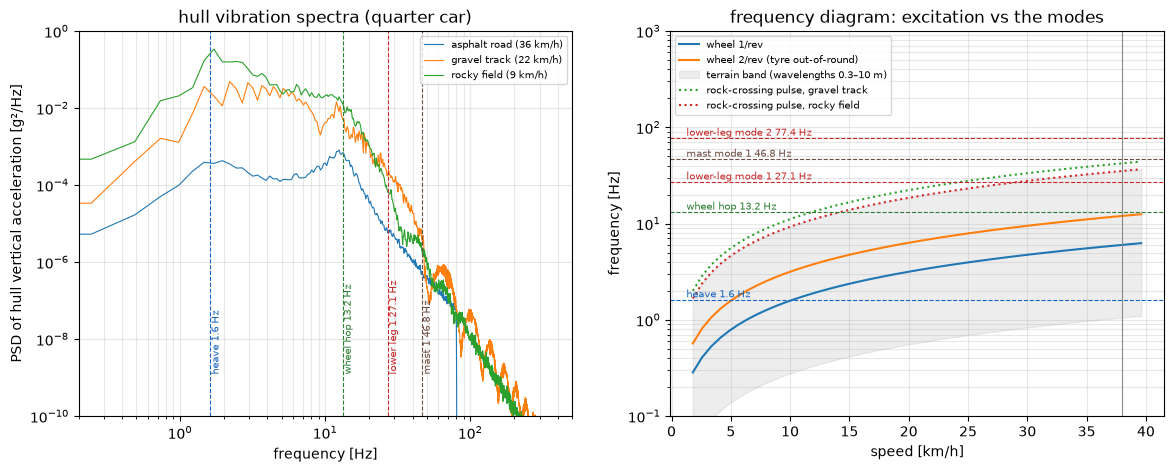

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for name, s in sims.items():
    f, P = welch(s["As"] / G, fs=2000.0, nperseg=8192)
    ax.loglog(f, P, lw=0.8, label=f"{name} ({s['speed'] * 3.6:.0f} km/h)")
for fr, lab_, col in ((f_heave, "heave", "#1565c0"), (f_hop, "wheel hop", "#2e7d32"), (f_leg[0], "lower leg 1", "#c62828"), (f_mast[0], "mast 1", "#6d4c41")):
    ax.axvline(fr, color=col, ls="--", lw=0.8); ax.text(fr, 1e-9, f" {lab_} {fr:.1f} Hz", rotation=90, color=col, fontsize=7, va="bottom")
ax.set(xlim=(0.2, 500), ylim=(1e-10, 1), xlabel="frequency [Hz]", ylabel="PSD of hull vertical acceleration [g²/Hz]", title="hull vibration spectra (quarter car)"); ax.legend(fontsize=7); ax.grid(alpha=0.3, which="both")
ax = axes[1]
speeds = np.linspace(0.5, 11.0, 50)
ax.plot(speeds * 3.6, speeds / (2 * math.pi * R_W), label="wheel 1/rev"); ax.plot(speeds * 3.6, 2 * speeds / (2 * math.pi * R_W), label="wheel 2/rev (tyre out-of-round)")
ax.fill_between(speeds * 3.6, speeds / 10.0, speeds / 0.3, color="#888", alpha=0.15, label="terrain band (wavelengths 0.3–10 m)")
for name, tr in TERRAINS.items():
    if tr["rocks"]: ax.plot(speeds * 3.6, speeds / tr["rocks"][1], ":", label=f"rock-crossing pulse, {name}")
for fr, lab_, col in ((f_heave, "heave", "#1565c0"), (f_hop, "wheel hop", "#2e7d32"), (f_leg[0], f"lower-leg mode 1", "#c62828"), (f_leg[1], f"lower-leg mode 2", "#c62828"), (f_mast[0], "mast mode 1", "#6d4c41")):
    ax.axhline(fr, color=col, ls="--", lw=0.8); ax.text(1.0, fr, f" {lab_} {fr:.1f} Hz", color=col, fontsize=7, va="bottom")
ax.axvline(SPEC["speed, wheels [km/h]"], color="#888", lw=0.8)
ax.set(xlabel="speed [km/h]", ylabel="frequency [Hz]", yscale="log", ylim=(0.1, 1000), title="frequency diagram: excitation vs the modes"); ax.legend(fontsize=7, loc="upper left"); ax.grid(alpha=0.3, which="both")
structure = chronos.Structure(tuple(f_leg) + tuple(f_mast[:1]), damping_ratio=0.03)
v_top = SPEC["speed, wheels [km/h]"] / 3.6
print(f"at {SPEC['speed, wheels [km/h]']} km/h the wheel turns at {v_top / (2 * math.pi * R_W):.1f} Hz; margin of the 2/rev to the nearest structural mode {structure.margin(2 * v_top / (2 * math.pi * R_W)):.2f} | the mast at {f_mast[0]:.0f} Hz sits above the terrain band: the head follows the hull (RMS {summary['hull_accel_rms_g'].max():.2f} g on the rocky field) and the gimbal must cancel {summary['pitch_rate_rms_deg_s'].max():.0f} deg/s RMS of pitch rate")

## 5. Static strength of the legs under the operating cases (Talos)

The lower leg is analysed in its own frame (knee bore fixed, force at the stub-axle bore), the upper leg in its
(shoulder bore fixed, the knee pin force). Ground forces (`fx` forward, `fy` lateral, `fz` up) are rotated into
each leg's frame with the standing angles. Cases: standing on the heavier rear corner, the walk's peak, braking
at full motor torque, the rock strike of the quarter-car's rocky field (its peak tyre force with the matching
longitudinal share), a 0.4 m drop landed on two wheels with the legs absorbing 0.15 m, and cornering at 0.4 g
(lateral: the plates' weak direction). The stub axle (cantilever to the wheel centre) and the knee pin (double
shear across the clevis) by hand.

In [15]:
STEEL_PIN = talos.Material("steel pin (42CrMo4)", youngs_modulus=210000.0, poissons_ratio=0.30, density=7.85e-9, yield_strength=650.0, source="handbook")
a1s, a2s = geo["a1"], geo["a2"]
def to_lower(fx, fz): return fx * math.cos(a2s) - fz * math.sin(a2s), fx * math.sin(a2s) + fz * math.cos(a2s)
def to_upper(fx, fz): return fx * math.cos(a1s) + fz * math.sin(a1s), -fx * math.sin(a1s) + fz * math.cos(a1s)
DROP_M, S_LEG = 0.40, 0.15                       # drop height and the legs' absorbing stroke [m] (inputs)
landing_mean = M_TOTAL * G * (DROP_M / S_LEG + 1) / 2
rock = sims["rocky field"]; i_rock = int(np.argmax(rock["Ft"]))
slope_rock = np.gradient(rock["zr"], rock["t"] * rock["speed"])
CASES = {
    "standing, rear wheel": dict(fx=0.0, fy=0.0, fz=float(fz_stand[2:].max())),
    "walk peak (β 0.75)": dict(fx=0.3 * wheel_peak(W, 0.75), fy=0.0, fz=wheel_peak(W, 0.75)),
    "braking, full motor torque": dict(fx=-HUB.stall_Nm / R_W, fy=0.0, fz=1.3 * W / 4),
    "rock strike, rocky field (quarter car)": dict(fx=float(rock["Ft"][i_rock] * min(abs(slope_rock[i_rock]), 1.0)), fy=0.0, fz=float(rock["Ft"][i_rock])),
    "drop landing 0.4 m on two wheels": dict(fx=0.2 * landing_mean * math.pi / 2, fy=0.0, fz=landing_mean * math.pi / 2),
    "cornering 0.4 g, outer wheel": dict(fx=0.0, fy=0.4 * W / 4 * 1.5, fz=1.5 * W / 4),
}
lower_model([talos.Force("axle", fz=1.0)], "mesh").mesh(RUNS / "lower_mesh", progress=True)
upper_model([talos.Force("knee", fz=1.0)], "mesh").mesh(RUNS / "upper_mesh", progress=True)
lower_results, upper_results = {}, {}
for name, f in tqdm(CASES.items(), desc="cases"):
    lx, lz = to_lower(f["fx"], f["fz"]); ux, uz = to_upper(f["fx"], f["fz"])
    key = "".join(ch if ch.isalnum() else "_" for ch in name)
    lm = lower_model([talos.Force("axle", fx=lx, fy=f["fy"], fz=lz)], key); lm.mesh(RUNS / f"lower_{key}"); lower_results[name] = lm.solve(RUNS / f"lower_{key}")
    um = upper_model([talos.Force("knee", fx=ux, fy=f["fy"], fz=uz)], key); um.mesh(RUNS / f"upper_{key}"); upper_results[name] = um.solve(RUNS / f"upper_{key}")
print({k: r.status for k, r in lower_results.items()})

talos mesh:   0%|          | 00:00 

import STEP:   0%|          | 00:00 

mesh 2D:   5%|▌         | 00:00     

mesh 3D + second order:  20%|██        | 00:00 

mesh 3D + second order:  40%|████      | 00:00 

...

cases:  67%|██████▋   | 4/6 [00:50<00:24, 12.43s/it]

cases:  83%|████████▎ | 5/6 [01:02<00:12, 12.29s/it]

cases: 100%|██████████| 6/6 [01:14<00:00, 12.43s/it]

cases: 100%|██████████| 6/6 [01:14<00:00, 12.46s/it]

{'standing, rear wheel': 'success', 'walk peak (β 0.75)': 'success', 'braking, full motor torque': 'success', 'rock strike, rocky field (quarter car)': 'success', 'drop landing 0.4 m on two wheels': 'success', 'cornering 0.4 g, outer wheel': 'success'}


worst lower-leg case: lower leg — drop landing 0.4 m on two wheels (SF 6.92)


,load,max_von_mises_MPa,SF_yield,deflection_mm
"lower leg — standing, rear wheel","fx 0, fy 0, fz 1060 N",7.672915,65.555264,0.194115
lower leg — walk peak (β 0.75),"fx 628, fy 0, fz 2093 N",12.250053,41.061048,0.302795
"lower leg — braking, full motor torque","fx -857, fy 0, fz 1299 N",13.654803,36.836854,0.347791
"lower leg — rock strike, rocky field (quarter car)","fx 8181, fy 0, fz 8181 N",21.437675,23.463366,0.450136
lower leg — drop landing 0.4 m on two wheels,"fx 2303, fy 0, fz 11513 N",72.69244,6.919564,1.812934
"lower leg — cornering 0.4 g, outer wheel","fx 0, fy 600, fz 1499 N",24.529907,20.505581,1.151188
"upper leg — standing, rear wheel","fx 0, fy 0, fz 1060 N",5.98197,84.086008,0.097102
upper leg — walk peak (β 0.75),"fx 628, fy 0, fz 2093 N",15.692223,32.054094,0.260249
"upper leg — braking, full motor torque","fx -857, fy 0, fz 1299 N",2.039467,246.633044,0.025673
"upper leg — rock strike, rocky field (quarter car)","fx 8181, fy 0, fz 8181 N",96.713109,5.20095,1.641911


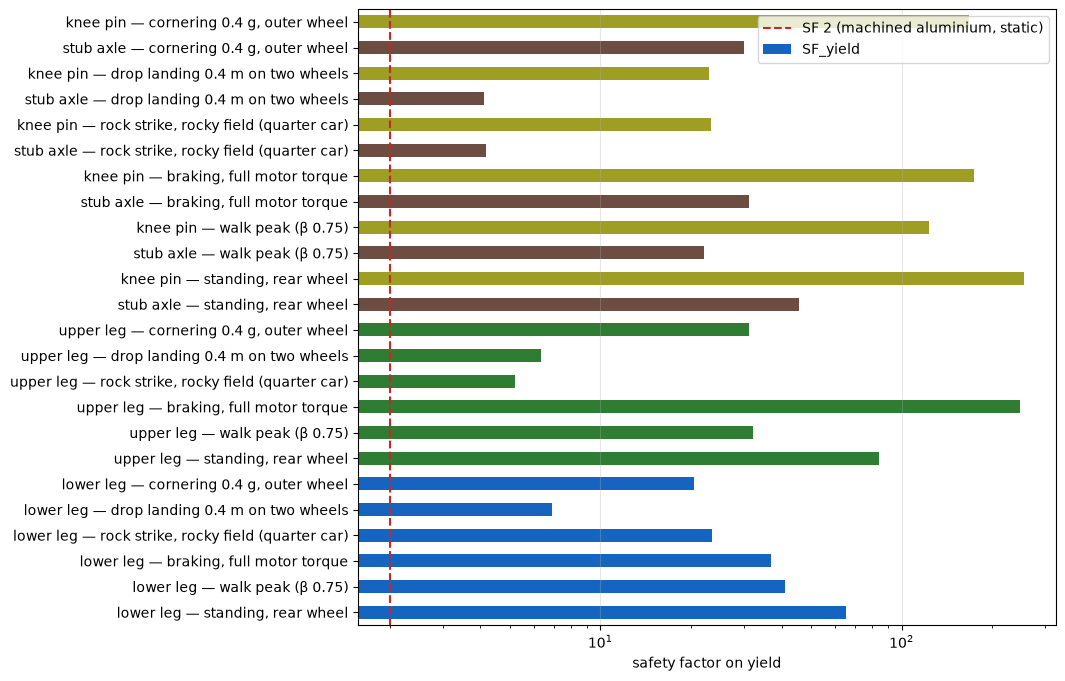

In [16]:
def pin_bending(F, lever_mm, d_mm): return F * lever_mm / (math.pi * d_mm**3 / 32)
def pin_shear(F, d_mm, n=2): return F / (n * math.pi * d_mm**2 / 4)
lever_axle = p["wheel_offset"] + p["wheel_width"] / 2                   # stub axle: cantilever from the lower leg to the wheel centre
lever_pin = (t_up / 2 + 4.0) / 2                                         # knee pin: bending over half the clevis gap
hand = {}
for name, f in CASES.items():
    F = math.sqrt(f["fx"]**2 + f["fy"]**2 + f["fz"]**2)
    s_axle = math.sqrt(pin_bending(F, lever_axle, p["axle_diameter"])**2 + 3 * pin_shear(F, p["axle_diameter"], 1)**2)
    s_pin = math.sqrt(pin_bending(F, lever_pin, p["pin_diameter"])**2 + 3 * pin_shear(F, p["pin_diameter"])**2)
    hand[f"stub axle — {name}"] = {"load": f"{F:.0f} N resultant", "max_von_mises_MPa": s_axle, "SF_yield": STEEL_PIN.yield_strength / s_axle, "deflection_mm": float("nan")}
    hand[f"knee pin — {name}"] = {"load": f"{F:.0f} N resultant", "max_von_mises_MPa": s_pin, "SF_yield": STEEL_PIN.yield_strength / s_pin, "deflection_mm": float("nan")}
def rows(results, label):
    return pd.DataFrame({f"{label} — {k}": {"load": f"fx {CASES[k]['fx']:.0f}, fy {CASES[k]['fy']:.0f}, fz {CASES[k]['fz']:.0f} N", "max_von_mises_MPa": r.metrics.get("max_von_mises"),
                                            "SF_yield": r.metrics.get("safety_factor_yield"), "deflection_mm": r.metrics.get("max_displacement")} for k, r in results.items()}).T
static = pd.concat([rows(lower_results, "lower leg"), rows(upper_results, "upper leg"), pd.DataFrame(hand).T])
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#1565c0"] * len(CASES) + ["#2e7d32"] * len(CASES) + ["#6d4c41", "#9e9d24"] * len(CASES)
static["SF_yield"].astype(float).plot.barh(ax=ax, color=colors)
ax.axvline(2.0, color="#c62828", ls="--", label="SF 2 (machined aluminium, static)"); ax.set(xlabel="safety factor on yield", xscale="log"); ax.legend(); ax.grid(alpha=0.3, axis="x")
worst_lower = static.loc[[k for k in static.index if k.startswith("lower")], "SF_yield"].astype(float).idxmin()
print(f"worst lower-leg case: {worst_lower} (SF {static.loc[worst_lower, 'SF_yield']:.2f})")
static.round(2)

/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:155: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), style="wireframe", color="#9aa5b1", opacity=0.25, line_width=0.5)
/home/user/vegeta/vegeta-cli/src/vegeta/talos/viz.py:323: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  return plotter.show(**kwargs)


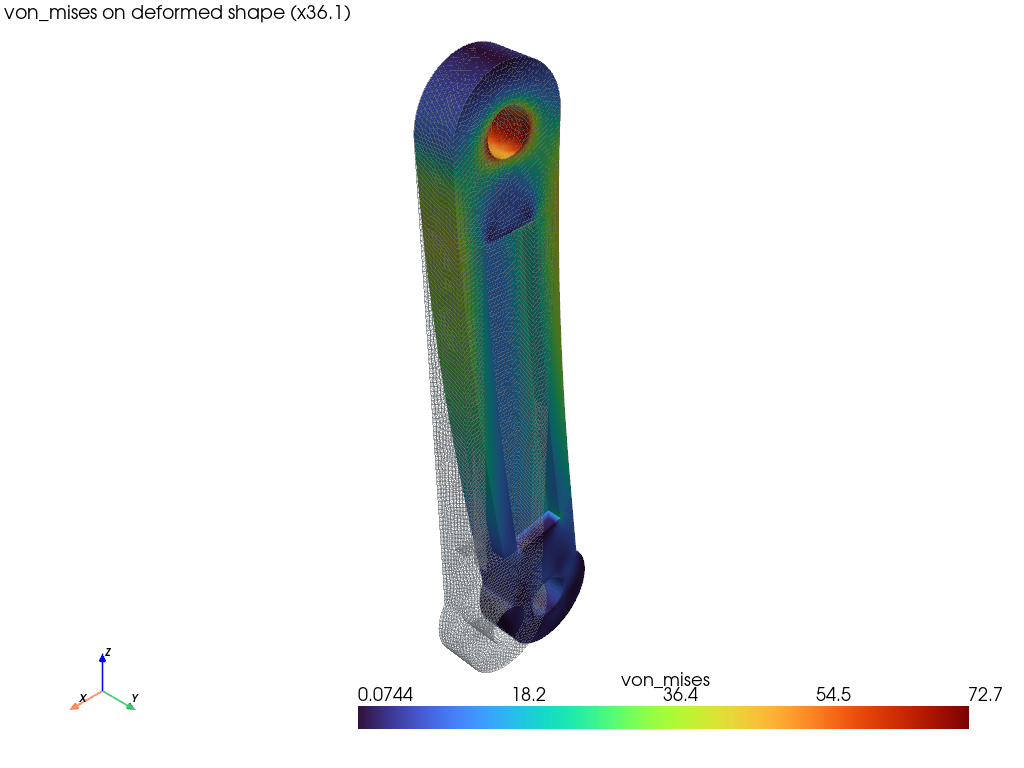

In [17]:
tviz.show(tviz.plot_results(lower_results[worst_lower.split(" — ")[1]], field="von_mises"))

## 6. Actuators simulated: torque–speed lines, a stand-up from the crouch, currents on the bus

Chiron's servo model (`vegeta.chiron.Servo`: a PD position loop clipped to the DC-motor line
`|τ| ≤ τ_stall (1 − |ω|/ω₀)`) is what the leg modules and hub motors run on in §7. Here it is exercised on its
own: the lines of the three catalogue actuators, then a knee lifting its corner of the hull out of a 200 mm
crouch — one degree of freedom, the knee's `kp`/`kd` and the gravity feed-forward of the controller, the torque
clipped to the line — with the current (`τ / k_t`, k_t from the stall point) and the electrical power
(`τ ω + i² R`). The thermal column compares what each duty asks of a module with its continuous rating.

stand-up: settled within 5 mm after 0.27 s | peak knee torque 800 N·m, peak speed 21 rpm of 40 | peak current 180 A per module (720 A on the 48 V bus for four knees) | energy 7.54 Wh for the four corners


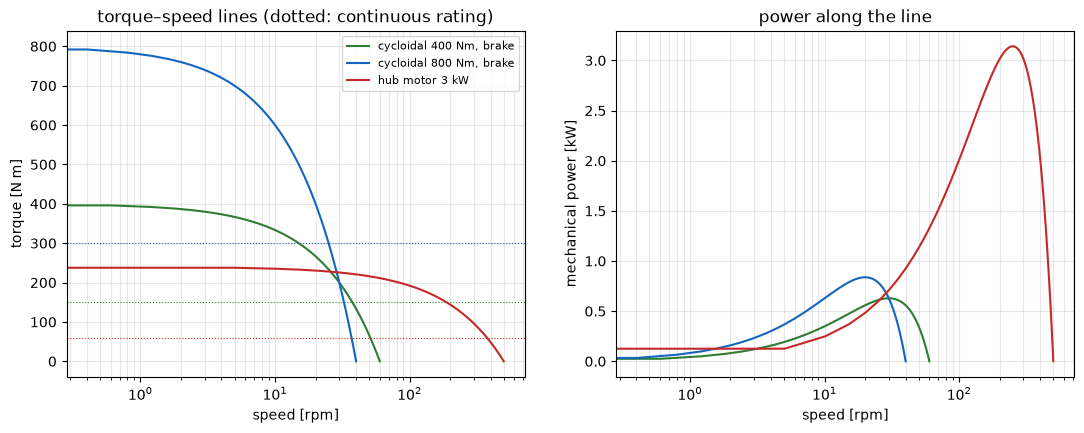

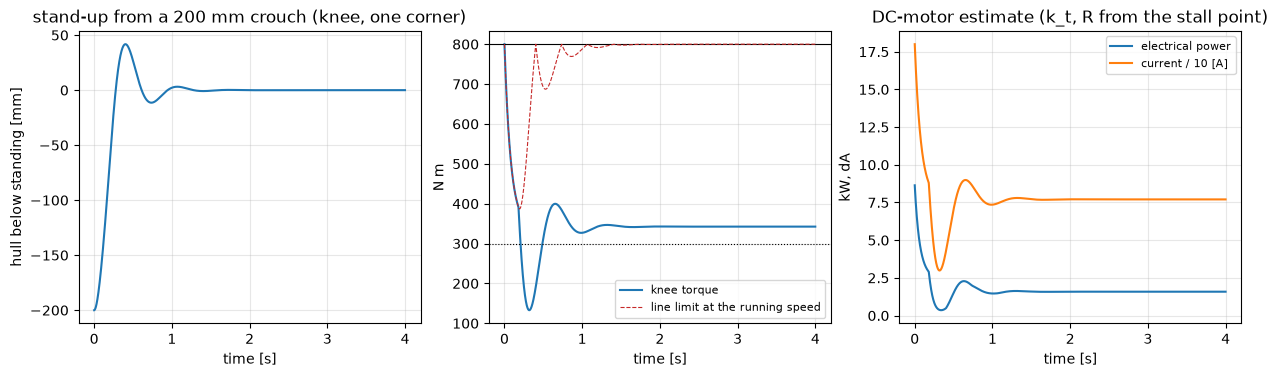

In [18]:
from vegeta.chiron import servo as cservo
leg_servo, hub_servo = orb.leg_servo(), orb.wheel_servo()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for key, col in (("cycloidal 400 Nm, brake", "#2e7d32"), ("cycloidal 800 Nm, brake", "#1565c0"), ("hub motor 3 kW", "#c62828")):
    a = act.get(key); w0 = a.no_load_rpm * 2 * math.pi / 60; w = np.linspace(0, w0, 100)
    tau = a.stall_Nm * (1 - w / w0)
    axes[0].plot(w * 60 / (2 * math.pi), tau, color=col, label=key); axes[0].axhline(a.rated_Nm, color=col, ls=":", lw=0.8)
    axes[1].plot(w * 60 / (2 * math.pi), tau * w / 1000, color=col, label=key)
axes[0].set(xlabel="speed [rpm]", ylabel="torque [N m]", title="torque–speed lines (dotted: continuous rating)", xscale="log"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, which="both")
axes[1].set(xlabel="speed [rpm]", ylabel="mechanical power [kW]", title="power along the line", xscale="log"); axes[1].grid(alpha=0.3, which="both")

CROUCH = 0.20                                                       # the hull 200 mm lower than standing [m] (input)
KT, R_LEG = leg_servo.torque_constant, leg_servo.resistance
def stand_up(kp=orb.LEG_KP, kd=orb.LEG_KD, dt=1e-3, t_end=4.0, gravity_ff=True):
    """One corner (M/4 on the knee): the knee goes from the crouch angle to the standing angle under the PD + line; returns the history."""
    q_stand = orb.nominal_qpos()["FL_knee"]
    q = q_stand - CROUCH / LEVER_KNEE; qd = 0.0
    I_eq = M_SPRUNG_CORNER * LEVER_KNEE**2 + orb.LEG_ARMATURE          # the corner's mass reflected to the knee (lever at the standing pose)
    tau_g = M_SPRUNG_CORNER * G * LEVER_KNEE                            # gravity torque at the knee (held constant: a small-angle model)
    hist = []
    for t in np.arange(0, t_end, dt):
        ff = tau_g if gravity_ff else 0.0
        tau = float(cservo.servo_torque(q, qd, q_stand, 0.0, ff, kp=kp, kd=kd, stall=leg_servo.stall_torque, no_load_speed=leg_servo.no_load_speed))
        i = abs(tau) / KT; P_el = abs(tau * qd) + i**2 * R_LEG
        hist.append((t, (q - q_stand) * LEVER_KNEE, qd, tau, i, P_el))
        qdd = (tau - tau_g) / I_eq
        qd += qdd * dt; q += qd * dt
    return pd.DataFrame(hist, columns=["t", "dz_m", "qd", "tau", "i", "P_el"])
su = stand_up()
settled = su[np.abs(su.dz_m) < 0.005].t.min()
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(su.t, su.dz_m * 1000); axes[0].set(xlabel="time [s]", ylabel="hull below standing [mm]", title=f"stand-up from a {CROUCH * 1000:.0f} mm crouch (knee, one corner)")
axes[1].plot(su.t, su.tau, label="knee torque"); axes[1].axhline(leg_servo.stall_torque, color="k", lw=0.8); axes[1].axhline(leg_servo.rated_torque, color="k", ls=":", lw=0.8); axes[1].plot(su.t, cservo.torque_limit(su.qd, leg_servo.stall_torque, leg_servo.no_load_speed), "--", color="#c62828", lw=0.8, label="line limit at the running speed"); axes[1].set(xlabel="time [s]", ylabel="N m"); axes[1].legend(fontsize=8)
axes[2].plot(su.t, su.P_el / 1000, label="electrical power"); axes[2].plot(su.t, su.i / 10, label="current / 10 [A]"); axes[2].set(xlabel="time [s]", ylabel="kW, dA", title="DC-motor estimate (k_t, R from the stall point)"); axes[2].legend(fontsize=8)
for ax in axes: ax.grid(alpha=0.3)
E_standup = getattr(np, "trapezoid", getattr(np, "trapz", None))(su.P_el, su.t) * 4 / 3600
print(f"stand-up: settled within 5 mm after {settled:.2f} s | peak knee torque {su.tau.abs().max():.0f} N·m, peak speed {su.qd.abs().max() * 60 / (2 * math.pi):.0f} rpm of {LEG.no_load_rpm:.0f} | peak current {su.i.max():.0f} A per module ({4 * su.i.max():.0f} A on the 48 V bus for four knees) | energy {E_standup:.2f} Wh for the four corners")

In [19]:
I_BATT_MAX = E_BATT_WH / 48.0 * 2.0                # a 2C LFP pack: 125 Ah → 250 A continuous (input)
thermal = pd.DataFrame({
    "standing, brakes off (knee)": {"module": LEG.key, "torque [Nm]": abs(tau_stand[1]), "continuous [Nm]": LEG.rated_Nm, "stall [Nm]": LEG.stall_Nm},
    "walk peak (knee)": {"module": LEG.key, "torque [Nm]": torques.loc["walk", "peak knee [Nm]"], "continuous [Nm]": LEG.rated_Nm, "stall [Nm]": LEG.stall_Nm},
    "stand-up peak (knee)": {"module": LEG.key, "torque [Nm]": su.tau.abs().max(), "continuous [Nm]": LEG.rated_Nm, "stall [Nm]": LEG.stall_Nm},
    "cruise 38 km/h on asphalt (hub)": {"module": HUB.key, "torque [Nm]": resistance(SPEC["speed, wheels [km/h]"] / 3.6, C_RR["asphalt"], 0) / 4 * R_W, "continuous [Nm]": HUB.rated_Nm, "stall [Nm]": HUB.stall_Nm},
    "20 % grade on gravel (hub)": {"module": HUB.key, "torque [Nm]": resistance(2.0, C_RR["gravel"], 20) / 4 * R_W, "continuous [Nm]": HUB.rated_Nm, "stall [Nm]": HUB.stall_Nm},
    "three-wheel limp, 20 % grade (hub)": {"module": HUB.key, "torque [Nm]": resistance(2.0, C_RR["gravel"], 20) / 3 * R_W, "continuous [Nm]": HUB.rated_Nm, "stall [Nm]": HUB.stall_Nm},
    "0–38 km/h run, peak (hub)": {"module": HUB.key, "torque [Nm]": HUB.stall_Nm * (1 - 0.0), "continuous [Nm]": HUB.rated_Nm, "stall [Nm]": HUB.stall_Nm},
}).T
thermal["duty"] = np.where(thermal["torque [Nm]"].astype(float) <= thermal["continuous [Nm]"].astype(float), "continuous", np.where(thermal["torque [Nm]"].astype(float) <= thermal["stall [Nm]"].astype(float), "PEAK: minutes, thermal model needed", "EXCEEDS STALL"))
print(f"bus: the 0–38 km/h run draws {accel.loc['gravel, flat', 'peak_motor_current_A'] * 4:.0f} A peak against the pack's {I_BATT_MAX:.0f} A (2C) — the drive must current-limit the launch")
thermal.round(1)

bus: the 0–38 km/h run draws 560 A peak against the pack's 250 A (2C) — the drive must current-limit the launch


,module,torque [Nm],continuous [Nm],stall [Nm],duty
"standing, brakes off (knee)","cycloidal 800 Nm, brake",468.61414,300.0,800.0,"PEAK: minutes, thermal model needed"
walk peak (knee),"cycloidal 800 Nm, brake",1019.201211,300.0,800.0,EXCEEDS STALL
stand-up peak (knee),"cycloidal 800 Nm, brake",800.0,300.0,800.0,"PEAK: minutes, thermal model needed"
cruise 38 km/h on asphalt (hub),hub motor 3 kW,13.089197,60.0,240.0,continuous
20 % grade on gravel (hub),hub motor 3 kW,63.437031,60.0,240.0,"PEAK: minutes, thermal model needed"
"three-wheel limp, 20 % grade (hub)",hub motor 3 kW,84.582708,60.0,240.0,"PEAK: minutes, thermal model needed"
"0–38 km/h run, peak (hub)",hub motor 3 kW,240.0,60.0,240.0,"PEAK: minutes, thermal model needed"


## 7. The Sentinel in MuJoCo (ChironLab): a patrol on gravel, a hub motor fails, a wheel seizes

The Chiron robot (`designs/onager_robot.py`) is the hull, the four legs and the wheels as rigid bodies with the
masses of §1, the leg modules as position servos (the active suspension of §4) and the hub motors as velocity
servos on their torque–speed lines, rolling resistance as a friction loss on each wheel hinge. The controller
(`designs/onager_controller.py`) drives at a speed with a skid-steer heading hold, holds the hull with a
gravity and contact-force feed-forward, and scripts the failures. The scenario (`designs/onager_scenario.py`, also
`scenarios/onager_patrol.py`): a gravel road (RMS 15 mm) with a 120 mm speed bump at 3 m/s; at 6 s the
front-left hub motor loses power and freewheels; at 9 s the rear-right wheel seizes. Both responses slow to
1.5 m/s (at 3 m/s the heading fight over a dragged tyre rolled the hull in the first runs); then:

* **drag** — keep driving on three motors, the braked tyre skids;
* **limp** — the three-wheel limp of the redundancy spec: the hull shifts 0.4 m forward on the three good legs so
  the CG leaves the seized corner's side of the diagonal, and the seized wheel lifts 100 mm.

Two things the first runs taught the controller, both in `designs/onager_controller.py`: a hub motor's full torque acts
~1 m below the shoulder and the 800 N·m module cannot react it through the leg (the leg swings to its limit), so
the wheel torque is clamped to 150 N·m; and the legs carry a feed-forward of their wheel's measured horizontal
contact force, or a dragged tyre folds its leg on the servo compliance.

Nothing is animated: gravity, contacts and the actuators' limits decide what happens. The failure rules are off
(the question is not pass/fail but what each response costs).

In [20]:
road = osc.gravel_road()
lab = orb.onager_lab(road, robot=robot, log_geoms=True)
print(f"{robot.name}: {robot.total_mass():.1f} kg, {len(robot.links())} links, {len(robot.joints())} joints ({len(robot.actuated_joints())} actuated), wheels {[f.name for f in robot.feet]} | terrain: {road}")
episodes, tables = {}, {}
for response in tqdm(osc.RESPONSES, desc="responses"):
    episodes[response] = osc.run(lab, response)
    tables[response] = osc.phase_table(episodes[response])
    episodes[response].save(RUNS / f"patrol_{response}.npz")
    print(response, "events:", episodes[response].log["events"])
phases = pd.concat(tables, names=["response", "phase"])
phases.round(2)

Onager Sentinel SX-1: 407.5 kg, 13 links, 12 joints (12 actuated), wheels ['FL', 'FR', 'RL', 'RR'] | terrain: Custom(name='gravel road (RMS 15 mm) with a 120 mm speed bump at x = 12 m')


responses:   0%|          | 0/2 [00:00<?, ?it/s]

responses:  50%|█████     | 1/2 [00:07<00:07,  7.90s/it]

drag events: [(6.0, 'FL', 'motor_off'), (9.0, 'RR', 'seized')]


responses: 100%|██████████| 2/2 [00:15<00:00,  7.94s/it]

responses: 100%|██████████| 2/2 [00:15<00:00,  7.94s/it]

limp events: [(6.0, 'FL', 'motor_off'), (9.0, 'RR', 'seized'), (9.0, 'RR', 'limp: hull shifts +0.40 m, wheel lifts 0.10 m')]


window_s mean_speed_m_s distance_m yaw_rms_deg  \
response phase                                                                 
drag     nominal                   2–6       2.989728  11.926354     0.05477   
         FL motor off              6–9       2.979683   8.908701    0.074962   
         RR seized + response  10.5–16       1.401707   7.697578    0.406609   
limp     nominal                   2–6       2.989728  11.926354     0.05477   
         FL motor off              6–9       2.979683   8.908701    0.074962   
         RR seized + response  10.5–16       1.431541   7.860981    0.213349   

                              lateral_max_m tilt_max_deg wheel_power_mech_W  \
response phase                                                                
drag     nominal                   0.019714     5.857571        1317.573055   
         FL motor off              0.019925     1.979198         785.435043   
         RR seized + response      0.072604      2.79034         1772.71017   
limp     nominal                   0.019714     5.857571        1317.573055   
         FL motor off              0.019925     1.979198         785.435043   
         RR seized + response      0.162998    11.543683         615.795364   

                              wheel_power_el_W   RR_drag_N RR_airborne  \
response phase                                                           
drag     nominal                   2160.092594  -12.349611      0.1275   
         FL motor off              1126.262723  -39.938871         0.1   
         RR seized + response      7425.791289   576.47563    0.021818   
limp     nominal                   2160.092594  -12.349611      0.1275   
         FL motor off              1126.262723  -39.938871         0.1   
         RR seized + response      1921.449279  136.216485    0.698182   

                              corner_load_max_N cost_of_transport  
response phase                                                     
drag     nominal                    3860.776099           0.11023  
         FL motor off               3738.005128          0.065932  
         RR seized + response       2458.560613          0.316328  
limp     nominal                    3860.776099           0.11023  
         FL motor off               3738.005128          0.065932  
         RR seized + response       3459.497035          0.107594

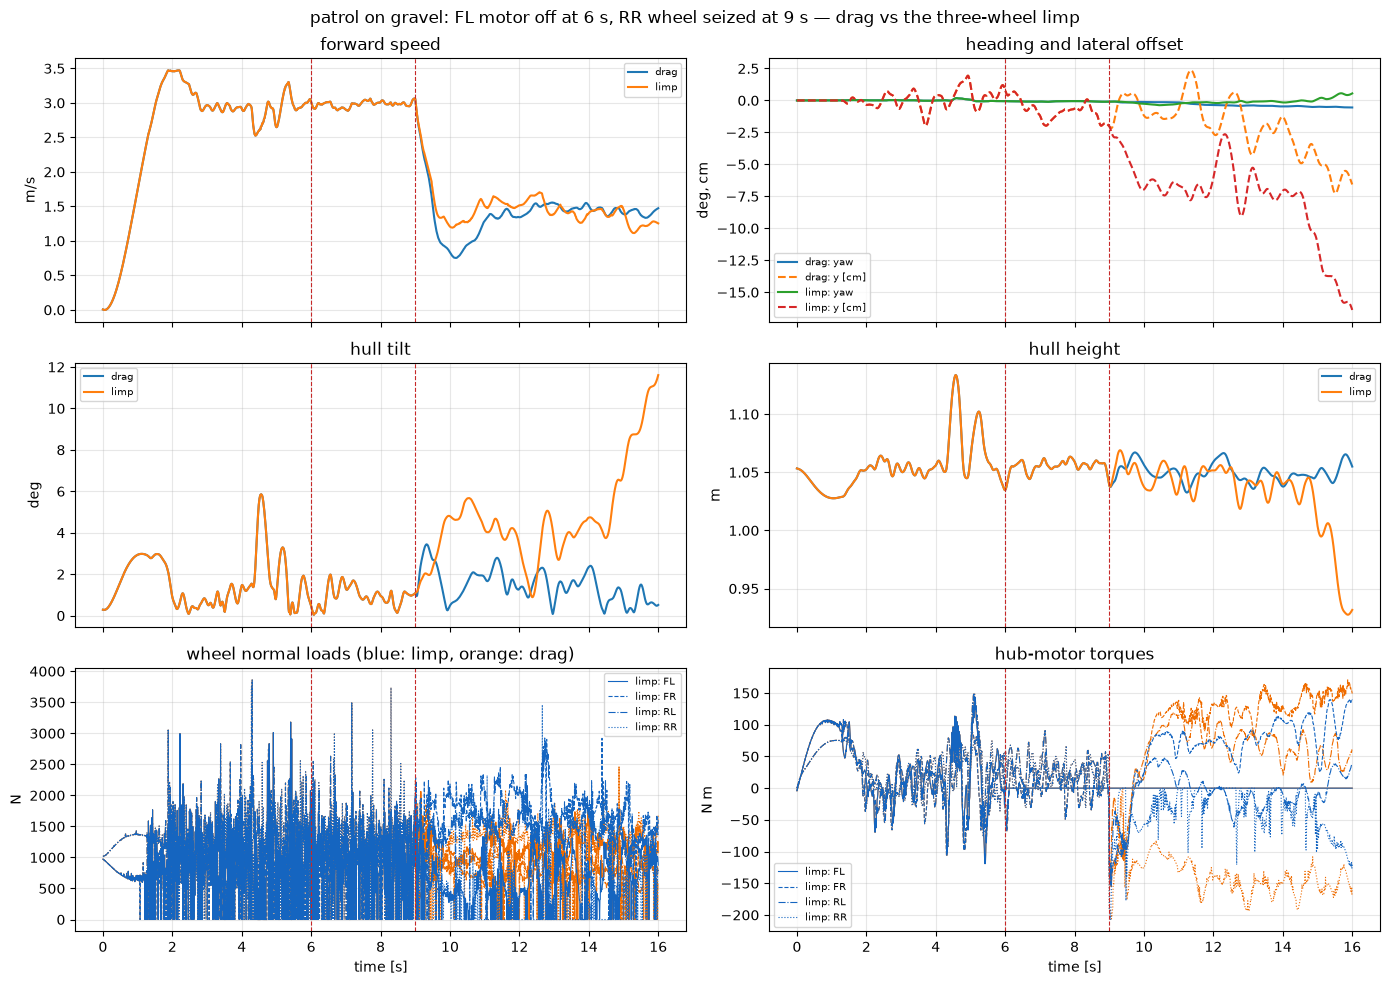

In [21]:
series = {r: osc.timeseries(ep) for r, ep in episodes.items()}
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
for r, ts in series.items():
    axes[0, 0].plot(ts.t, ts.v, label=r); axes[0, 1].plot(ts.t, ts.yaw_deg, label=f"{r}: yaw"); axes[0, 1].plot(ts.t, ts.y * 100, "--", label=f"{r}: y [cm]")
    axes[1, 0].plot(ts.t, ts.tilt_deg, label=r); axes[1, 1].plot(ts.t, ts.hull_z, label=r)
    for w, ls in zip(("FL", "FR", "RL", "RR"), ("-", "--", "-.", ":")):
        axes[2, 0].plot(ts.t, ts[f"fz_{w}"], ls, label=f"{r}: {w}" if r == "limp" else None, color="#1565c0" if r == "limp" else "#ef6c00", lw=0.8)
        axes[2, 1].plot(ts.t, ts[f"tau_{w}"], ls, label=f"{r}: {w}" if r == "limp" else None, color="#1565c0" if r == "limp" else "#ef6c00", lw=0.8)
for ax, (title, ylab) in zip(axes.flat, (("forward speed", "m/s"), ("heading and lateral offset", "deg, cm"), ("hull tilt", "deg"), ("hull height", "m"), ("wheel normal loads (blue: limp, orange: drag)", "N"), ("hub-motor torques", "N m"))):
    for f in osc.FAILURES: ax.axvline(f.t, color="#c62828", lw=0.8, ls="--")
    ax.set(title=title, ylabel=ylab); ax.grid(alpha=0.3); ax.legend(fontsize=7)
for ax in axes[-1]: ax.set(xlabel="time [s]")
fig.suptitle("patrol on gravel: FL motor off at 6 s, RR wheel seized at 9 s — drag vs the three-wheel limp"); fig.tight_layout()

movie: output/20_onager_sentinel/onager_patrol_drag.mp4 (401 frames, 16 s)


movie: output/20_onager_sentinel/onager_patrol_limp.mp4 (401 frames, 16 s)


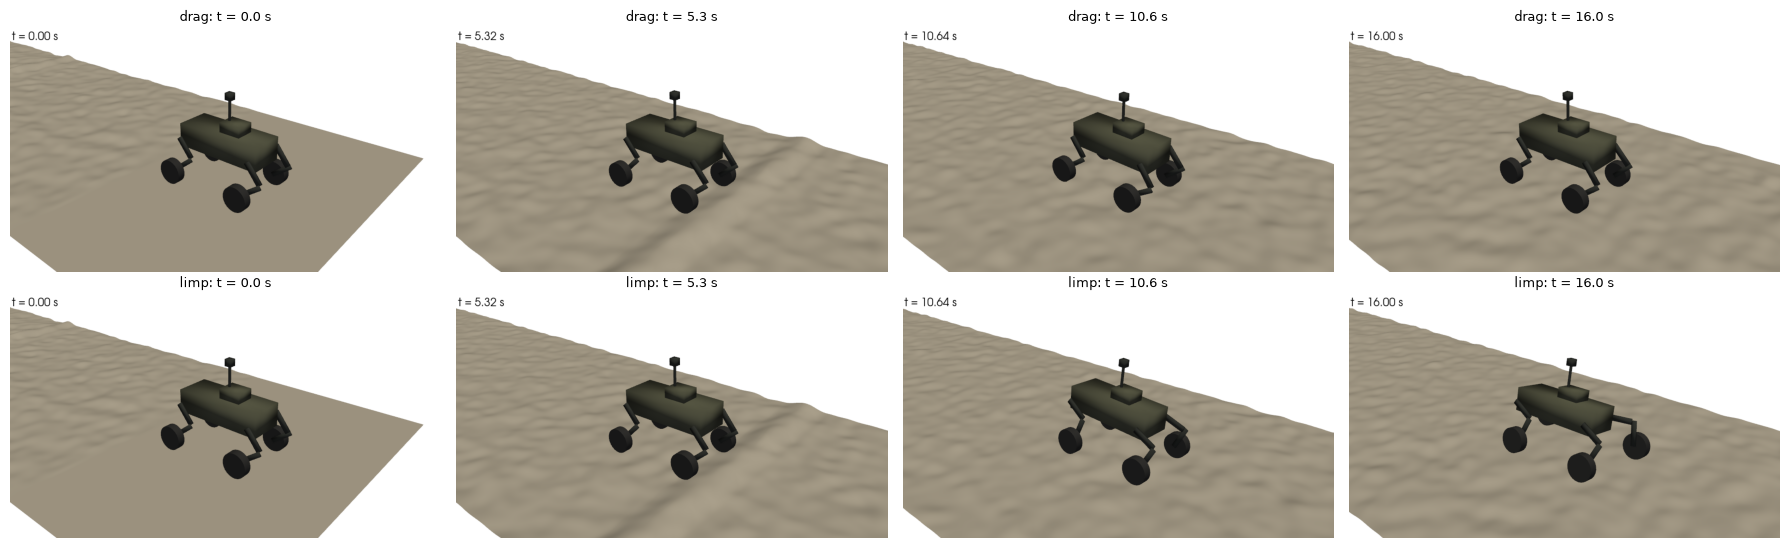

In [22]:
movies, strips = {}, {}
for response, ep in episodes.items():
    dt = float(ep.log["t"][1] - ep.log["t"][0]); every = max(1, int(round(1 / (25 * dt))))
    imgs = cviz.frames(ep, camera="follow", every=every, size=(960, 540))
    movies[response] = cviz.to_video(imgs, OUT / f"onager_patrol_{response}.mp4", fps=25)
    strips[response] = imgs
    print(f"movie: {movies[response]} ({len(imgs)} frames, {osc.DURATION:.0f} s)")
fig, axes = plt.subplots(2, 4, figsize=(18, 5.6))
for row, response in zip(axes, episodes):
    imgs = strips[response]
    for ax, j in zip(row, np.linspace(0, len(imgs) - 1, 4).astype(int)):
        ax.imshow(imgs[j]); ax.set_axis_off(); ax.set_title(f"{response}: t = {j * osc.DURATION / (len(imgs) - 1):.1f} s", fontsize=9)
fig.tight_layout()

## 8. Export

In [23]:
summary_doc = {"source": "20_onager_sentinel", "design": {"file": "designs/onager.py", "parameters": p}, "datasheet": SPEC.to_dict(),
           "envelope_m": envelope.to_dict(), "mass_kg": M_TOTAL, "mass_budget_kg": budget, "cg_mm_from_hull_centre": float(com_stand[0] * 1000), "rear_share": float(REAR_SHARE),
           "actuators": {"leg": LEG.as_dict(), "hub": HUB.as_dict()},
           "wheel_mode": {"top_speed_kmh": {f"{gr}% {surf}": v * 3.6 for (gr, surf), v in top_speed.items()}, "continuous_grade_deg": grade_cont, "acceleration": accel.to_dict(orient="index"), "endurance": endurance.to_dict(orient="index")},
           "walking_mode": {"torques": torques.to_dict(orient="index"), "speed_limits": walk_speed.to_dict(orient="index"), "holding_power_W": hold},
           "suspension": {"k_susp_N_m": K_SUSP, "zeta": ZETA, "k_tyre_N_m": K_TYRE, "f_heave_hz": f_heave, "f_hop_hz": f_hop, "terrains": summary.to_dict(orient="index")},
           "modes_hz": {"lower_leg_with_wheel": f_leg, "mast": f_mast},
           "static": static.to_dict(orient="index"), "worst_lower_leg_case": worst_lower,
           "stand_up": {"crouch_m": CROUCH, "settle_s": float(settled), "peak_torque_Nm": float(su.tau.abs().max()), "energy_Wh_4_corners": float(E_standup)},
           "thermal": thermal.to_dict(orient="index"),
           "patrol": {"terrain": road.spec(), "failures": [(f.t, f.wheel, f.mode) for f in osc.FAILURES], "responses": osc.RESPONSES,
                      "phases": {r: t.to_dict(orient="index") for r, t in tables.items()}, "events": {r: ep.log["events"] for r, ep in episodes.items()}, "movies": {r: str(m_) for r, m_ in movies.items()}}}
(RUNS / "onager_sentinel.json").write_text(json.dumps(summary_doc, indent=2, default=float))
print("written:", sorted(x.name for x in RUNS.iterdir())[:12], "...")

written: ['cad', 'lower_braking__full_motor_torque', 'lower_cornering_0_4_g__outer_wheel', 'lower_drop_landing_0_4_m_on_two_wheels', 'lower_mesh', 'lower_modal', 'lower_rock_strike__rocky_field__quarter_car_', 'lower_standing__rear_wheel', 'lower_walk_peak__β_0_75_', 'mast.step', 'mast_modal', 'onager.py'] ...


**What the numbers say** — read them in the tables above; the ones to look at first: the mass budget against the
datasheet's 380 kg (the eight 11 kg joint modules are the biggest item: a 400 N·m class at the shoulders saves
18 kg if the stance torques allow it); the walking speed the 40 rpm modules allow against the datasheet's
6 km/h; the standing knee torque against the module's continuous rating (the holding brake is load-bearing
equipment, not a convenience); the lateral cornering case on the H-section plates; and in §7 the cost of each
response to the seized wheel — distance made good, tilt, wheel power, and whether the lifted wheel stays up on
gravel.

**Next steps an engineer would take:** measure a real hub motor's torque–speed curve and thermal time constant
(the "peak" rows of the thermal table have no duration yet); replace the DC-motor current estimate with the
inverter's; measure the tyre's stiffness and rolling resistance (they set the loads and the range more than
anything in the CAD); add the hub motor's torque reaction and a lateral stiffness to the lower-leg FEA; give the
limp a hull-levelling loop (the tilt on gravel) and a speed schedule; and walk the Sentinel over a kerb in
ChironLab — a stepping gait for wheel-legs with the CG shift of the limp as its first move.